# Средняя носовая раковина в день операции

# Подготовка

## Настройка графики

In [1]:
# windows.options(height=5.4, width=7)
oldpar <- par()
par(mar = c(8, 4, 1, 2), "xpd" = FALSE)
options(repr.plot.height = 9, repr.plot.width = 12)
options(warn = -1)

## Библиотеки

In [2]:
options(java.parameters = "-Xmx4096m")

require(readxl, quietly = TRUE, warn.conflicts = FALSE)

require(vcd, quietly = TRUE, warn.conflicts = FALSE)
require(coin, quietly = TRUE, warn.conflicts = FALSE)
# independence_test
require(agricolae, quietly = TRUE, warn.conflicts = FALSE)
# HSD.test
require(pgirmess, quietly = TRUE, warn.conflicts = FALSE)
# kruskalmc
require(nortest, quietly = TRUE, warn.conflicts = FALSE)
# for normality test in case of N>5000. ad.test -- Anderson-Darling normality test
require(RcmdrMisc, quietly = TRUE, warn.conflicts = FALSE)
# numSumm

require(beeswarm, quietly = TRUE, warn.conflicts = FALSE)
require(lattice, quietly = TRUE, warn.conflicts = FALSE)
require(mosaic, quietly = TRUE, warn.conflicts = FALSE)
require(ggplot2, quietly = TRUE, warn.conflicts = FALSE)
require(ggpubr, quietly = TRUE, warn.conflicts = FALSE)
# ggqqplot
# require(ggExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(gridExtra, quietly = TRUE, warn.conflicts = FALSE);
# require(ggfortify, quietly = TRUE, warn.conflicts = FALSE);
require(ggalluvial, quietly = TRUE)
# flow diagramm
require(hrbrthemes, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(GGally, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord
require(viridis, quietly = TRUE, warn.conflicts = FALSE)
# ggparcoord


require(rstatix, quietly = TRUE)
# identify_outliers
require(dplyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidyr, quietly = TRUE, warn.conflicts = FALSE)
require(tidycmprsk, quietly = TRUE, warn.conflicts = FALSE)
# require(tidyverse, quietly = TRUE, warn.conflicts = FALSE);

require(IRdisplay, quietly = TRUE, warn.conflicts = FALSE)
require(repr, quietly = TRUE, warn.conflicts = FALSE)

require(knitr, quietly = TRUE, warn.conflicts = FALSE)
# Dynamic reports

Registered S3 method overwritten by 'mosaic':
  method                           from   
  fortify.SpatialPolygonsDataFrame ggplot2




The 'mosaic' package masks several functions from core packages in order to add 
additional features.  The original behavior of these functions should not be affected by this.



Registered S3 method overwritten by 'GGally':
  method from   
  +.gg   ggplot2




Attaching package: 'rstatix'




The following objects are masked from 'package:mosaic':

    cor_test, prop_test, t_test




The following objects are masked from 'package:coin':

    chisq_test, friedman_test, kruskal_test, sign_test, wilcox_test




The following object is masked from 'package:stats':

    filter




## Данные

### Загрузка

In [3]:
# sessionInfo()
# options(encoding = "UTF-8")
lor <- read_excel("C:\\Analysis\\OTOLARING\\Nidelko\\mucous20240825.xlsx", sheet = "данные")
# lor = as.data.frame(lor)

### Преобразование

#### Отбор данных

In [4]:
lor <- lor %>%
  dplyr::select(
    "id", "группа", "локация", "этап", "поле", "круглоклеточная воспалительная инфильтрация",
    "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
    "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
  ) %>%
  filter(локация != "полип") %>%
  filter(этап == "день операции")
lor <- as.data.frame(lor)

#### Контрасты

In [5]:
lor$группа <- factor(lor$группа, c("ОГ", "КГ", "КГ1"))
lor$"локация" <- factor(lor$"локация")
lor$"этап" <- factor(lor$"этап", c("день операции", "6-7 сутки", "1-3 мес.", "1 год"))

#### Медианные значения

In [6]:
lor_mean <- lor %>%
  group_by(id, группа, локация, этап) %>%
  summarise(
    across(
      c(
        "круглоклеточная воспалительная инфильтрация",
        "бокаловидные клетки", "отек", "реснички эпителия", "фиброз", "гиперплазия респираторного эпителия",
        "плоскоклеточная метаплазия", "эозинофилы", "нейтрофилы"
      ),
      ~ median(.x, na.rm = TRUE)
    ),
    .groups = "drop"
    # mean_value = mean(measurement_value, na.rm = TRUE),
    # median_value = median(measurement_value, na.rm = TRUE),
    # sd_value = sd(measurement_value, na.rm = TRUE),
    # min_value = min(measurement_value, na.rm = TRUE),
    # max_value = max(measurement_value, na.rm = TRUE)
  ) %>%
  arrange(id)
# %>%
#     kable(digits = 2)
# lor_mean

### Подключение

In [7]:
try(detach(lor), silent = TRUE)
attach(lor)

# Общий анализ

In [8]:
groupping_variable <- "группа"

## круглоклеточная воспалительная инфильтрация

### Общее

In [9]:
parname <- "круглоклеточная воспалительная инфильтрация"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

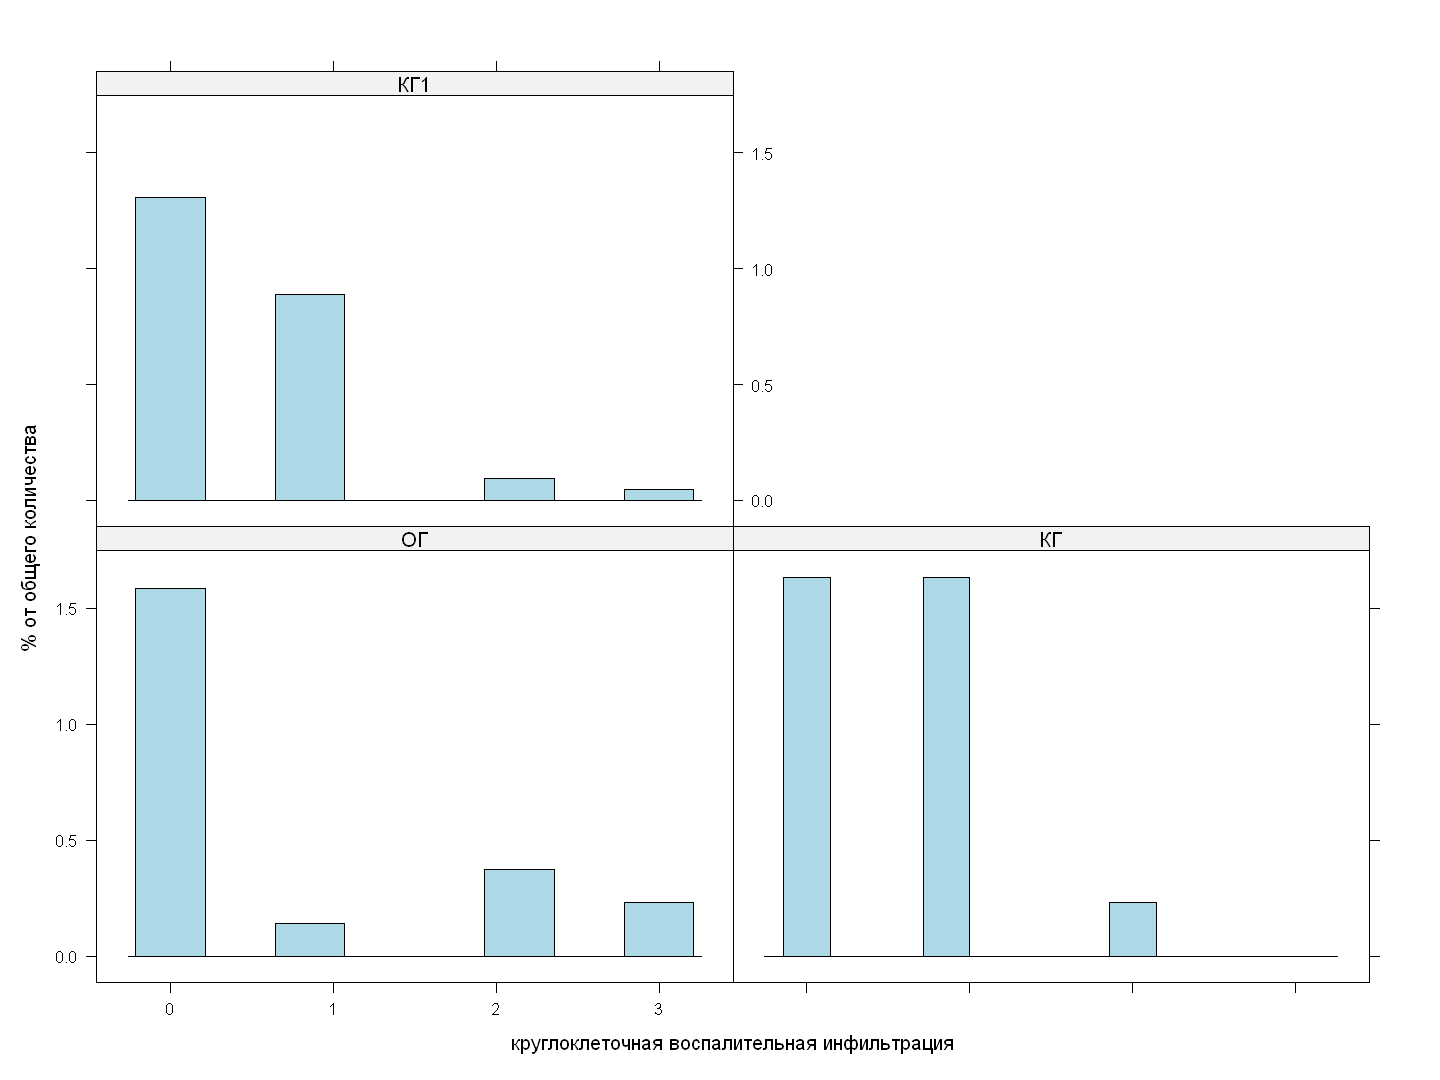

In [10]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [11]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean        sd  IQR 0% 25% 50%  75% 100% data:n
ОГ  0.68 1.0774119 1.75  0   0   0 1.75    3     50
КГ  0.60 0.6324555 1.00  0   0   1 1.00    2     15
КГ1 0.52 0.6773297 1.00  0   0   0 1.00    3     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,1.75,3,0.68,1.0774119,50,0
КГ,0,0,1,1.00,2,0.60,0.6324555,15,0
КГ1,0,0,0,1.00,3,0.52,0.6773297,50,0


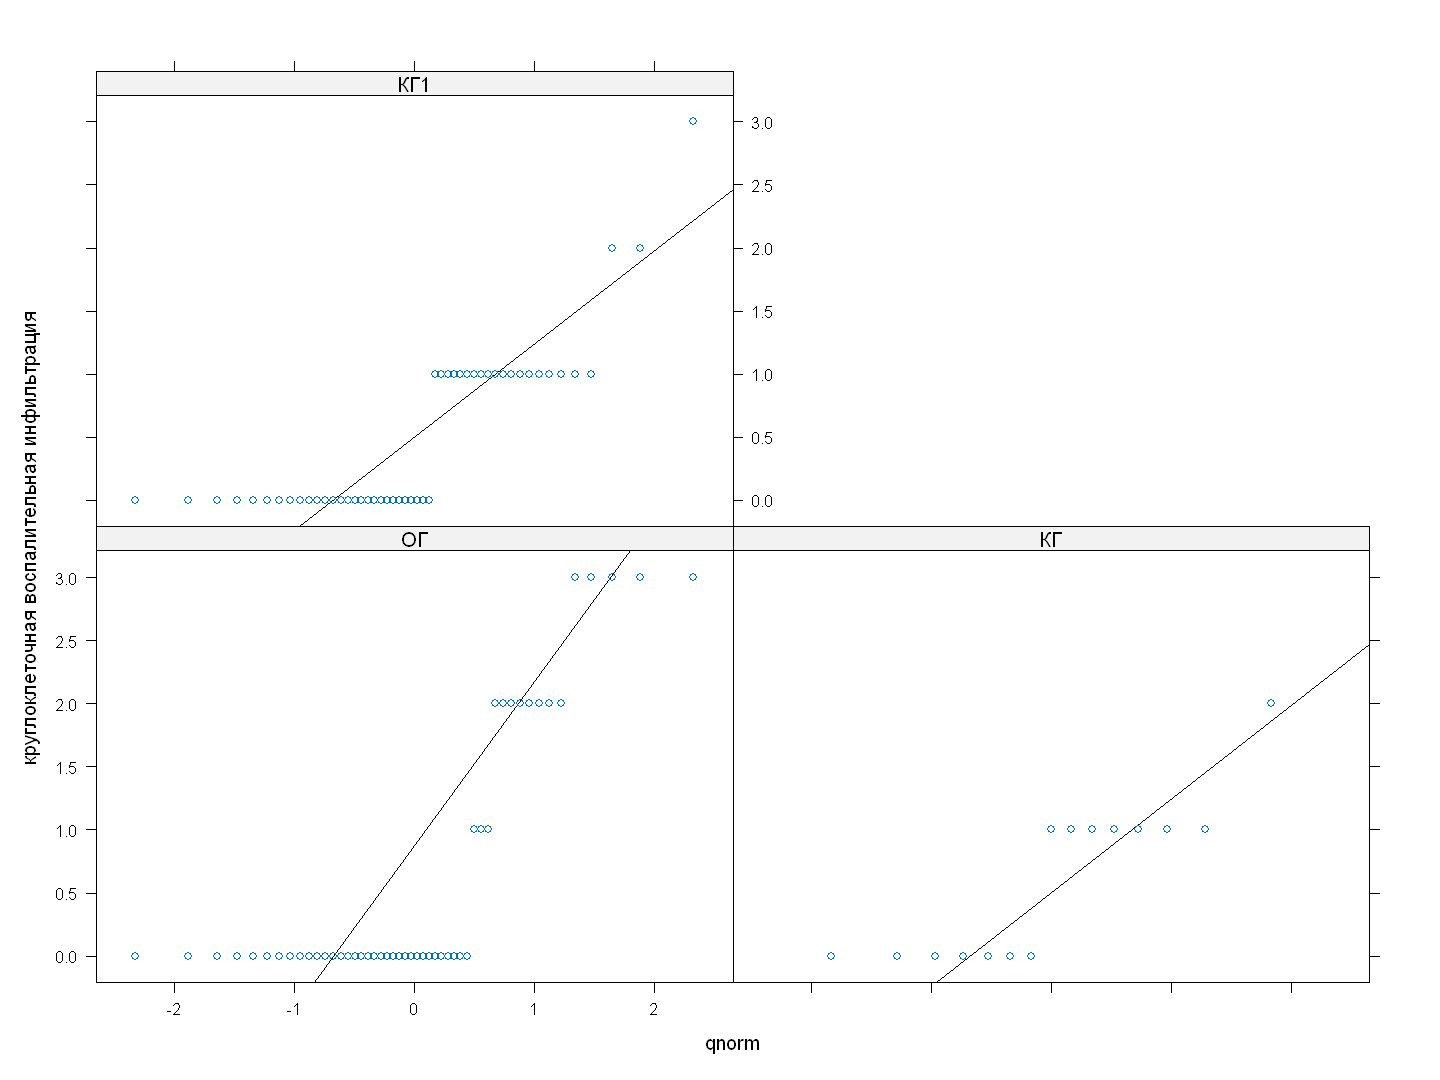

In [12]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

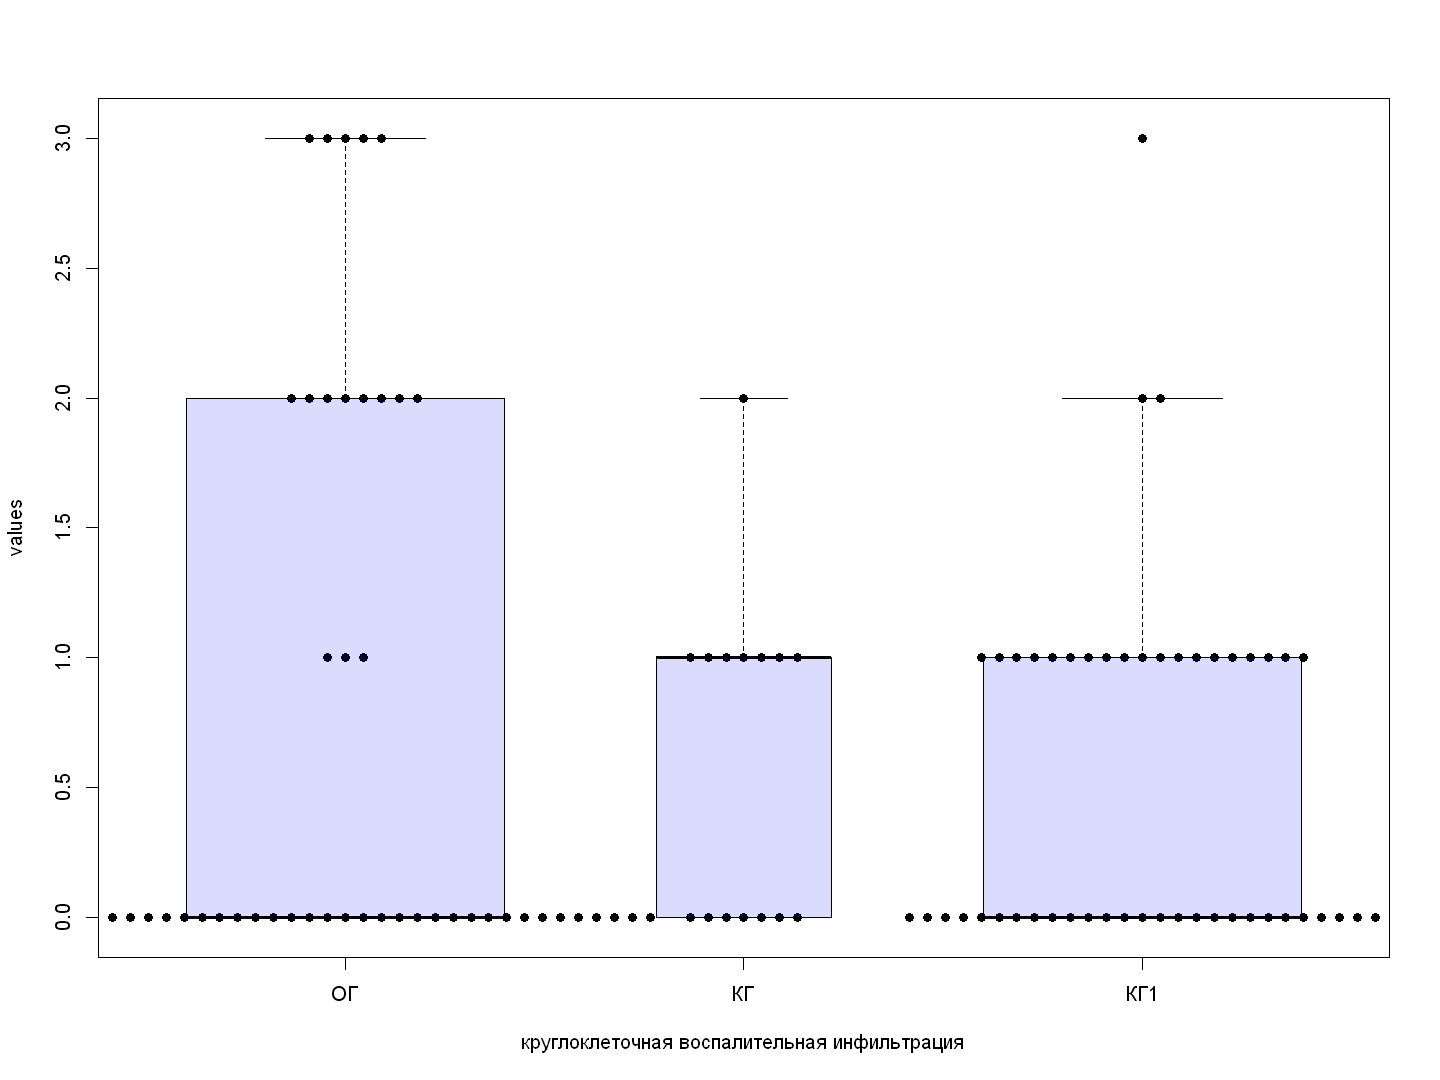

In [13]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [14]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 0.44585, df = 2, p-value = 0.8002

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  5.736667     23.49816       FALSE
ОГ-КГ1 1.200000     15.96385       FALSE
КГ-КГ1 4.536667     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 341.5, p-value = 0.551
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -0.60534, p-value = 0.5748
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1220, p-value = 0.8143
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

da

## бокаловидные клетки

### Общее

In [15]:
parname <- "бокаловидные клетки"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [16]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [17]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.08 0.3404679   0  0   0   0   0    2     50
КГ  0.00 0.0000000   0  0   0   0   0    0     15
КГ1 0.38 0.6667007   1  0   0   0   1    2     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,2,0.08,0.3404679,50,0
КГ,0,0,0,0,0,0.00,0.0000000,15,0
КГ1,0,0,0,1,2,0.38,0.6667007,50,0


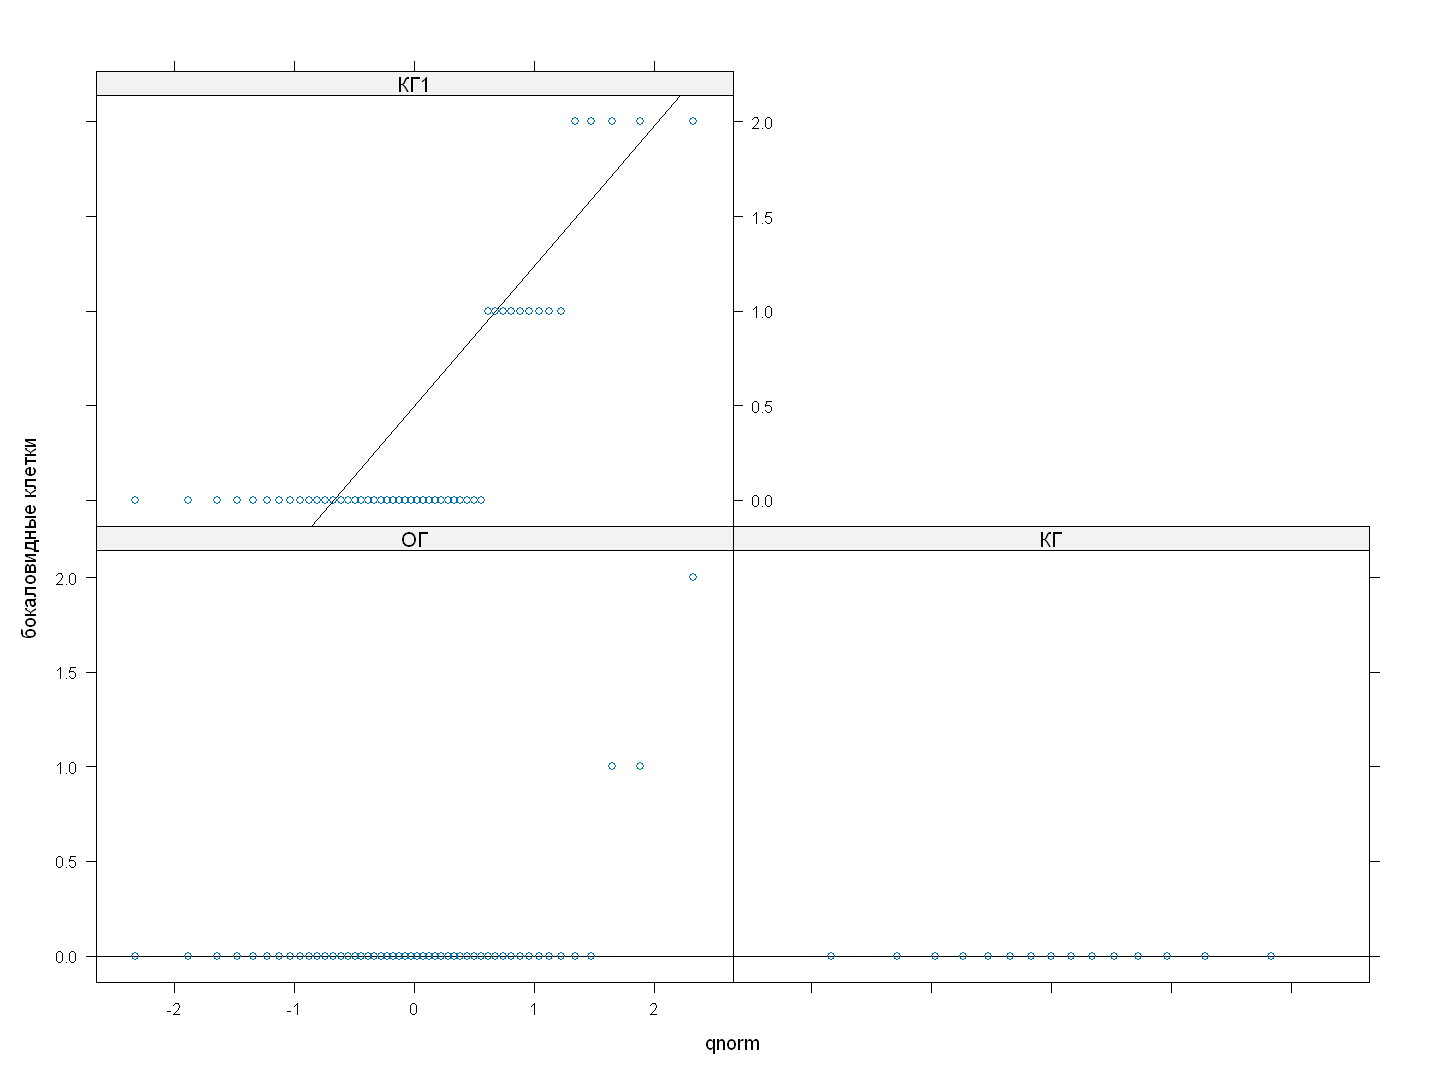

In [18]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

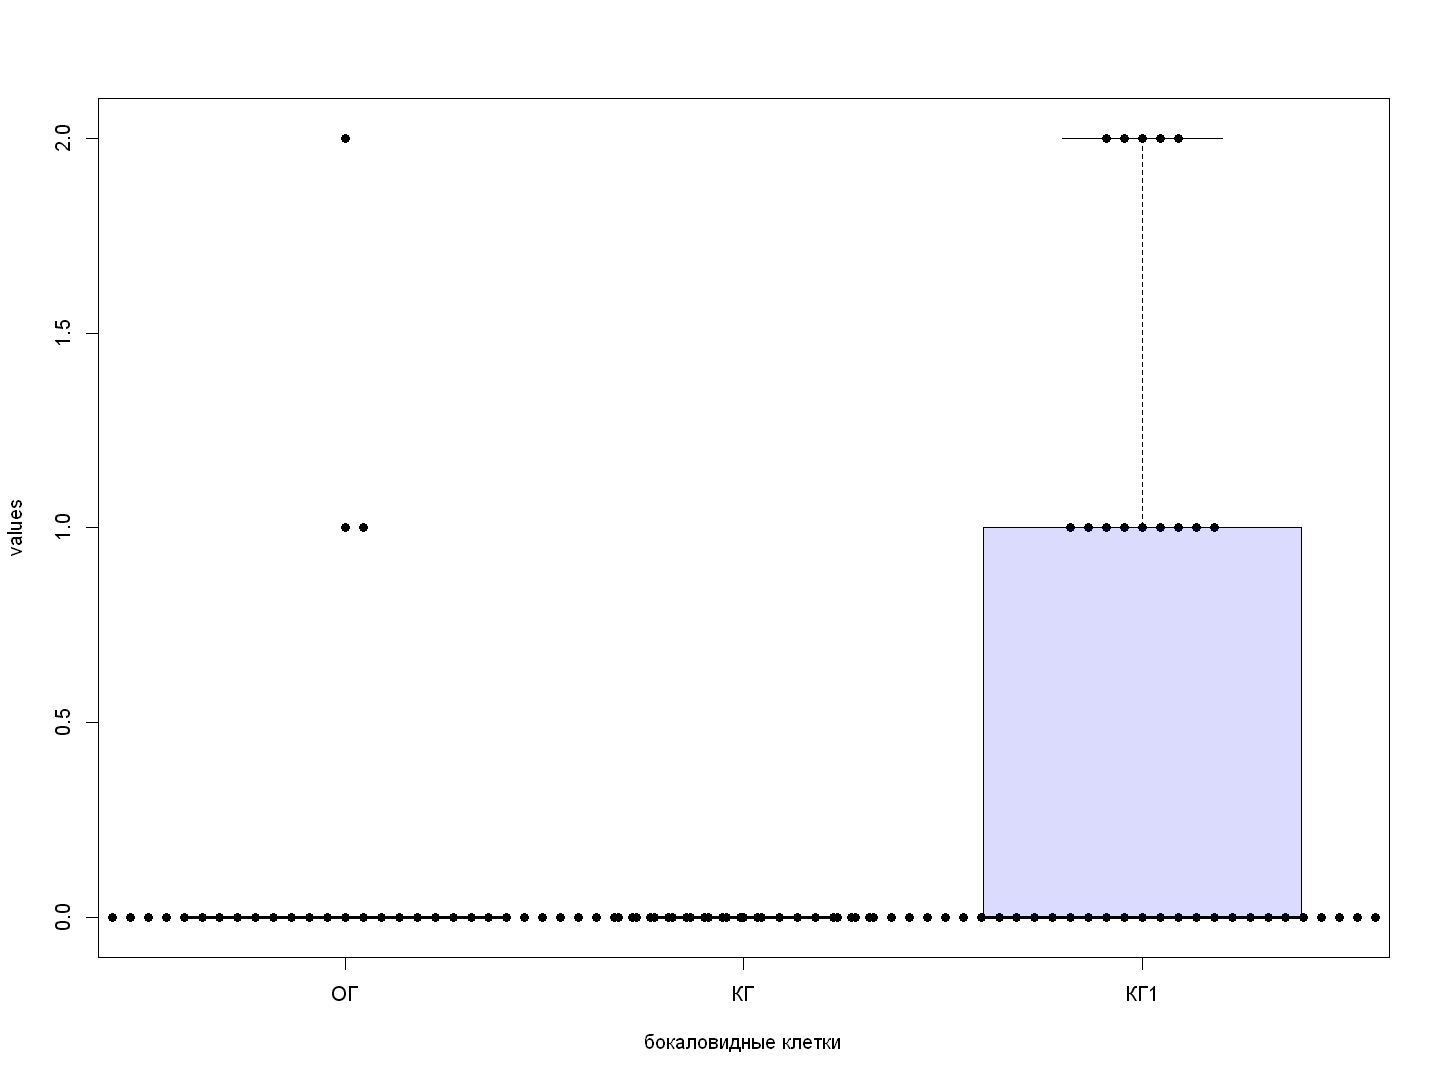

In [19]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [20]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 12.445, df = 2, p-value = 0.001984

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
       obs.dif critical.dif stat.signif
ОГ-КГ     3.44     23.49816       FALSE
ОГ-КГ1   12.67     15.96385       FALSE
КГ-КГ1   16.11     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 397.5, p-value = 0.3461
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 0.96362, p-value = 0.5793
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 974.5, p-value = 0.003706
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

da

## отек

### Общее

In [21]:
parname <- "отек"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

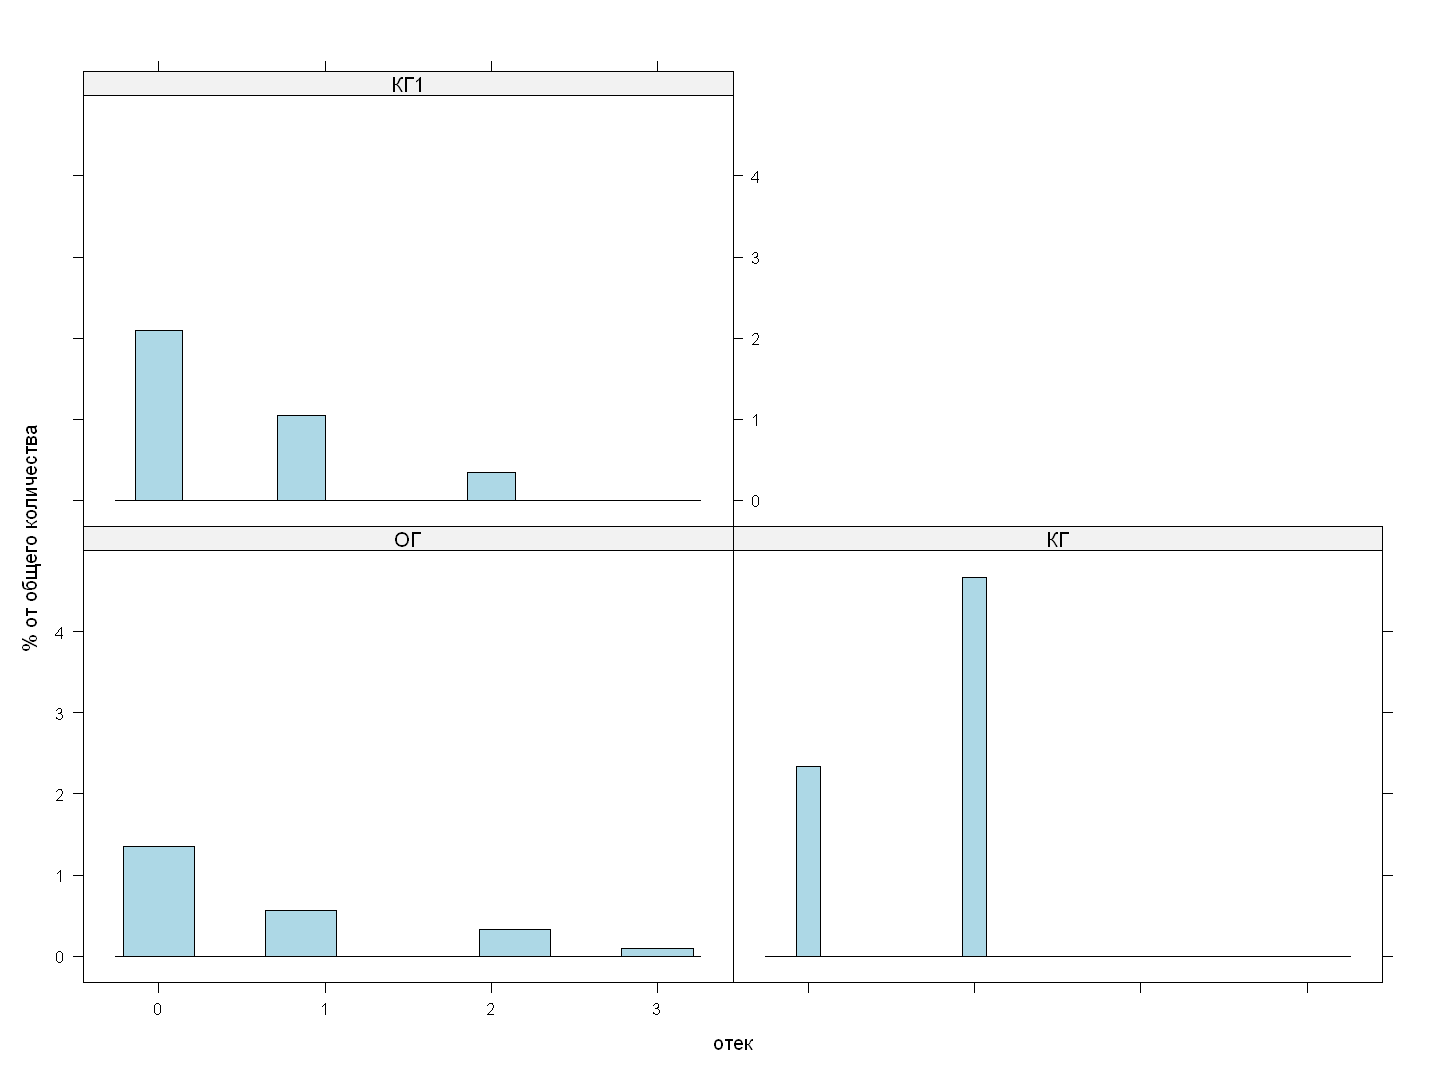

In [22]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [23]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.6400000 0.8750510   1  0   0   0   1    3     50
КГ  0.6666667 0.4879500   1  0   0   1   1    1     15
КГ1 0.5000000 0.6776309   1  0   0   0   1    2     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,1,3,0.6400000,0.8750510,50,0
КГ,0,0,1,1,1,0.6666667,0.4879500,15,0
КГ1,0,0,0,1,2,0.5000000,0.6776309,50,0


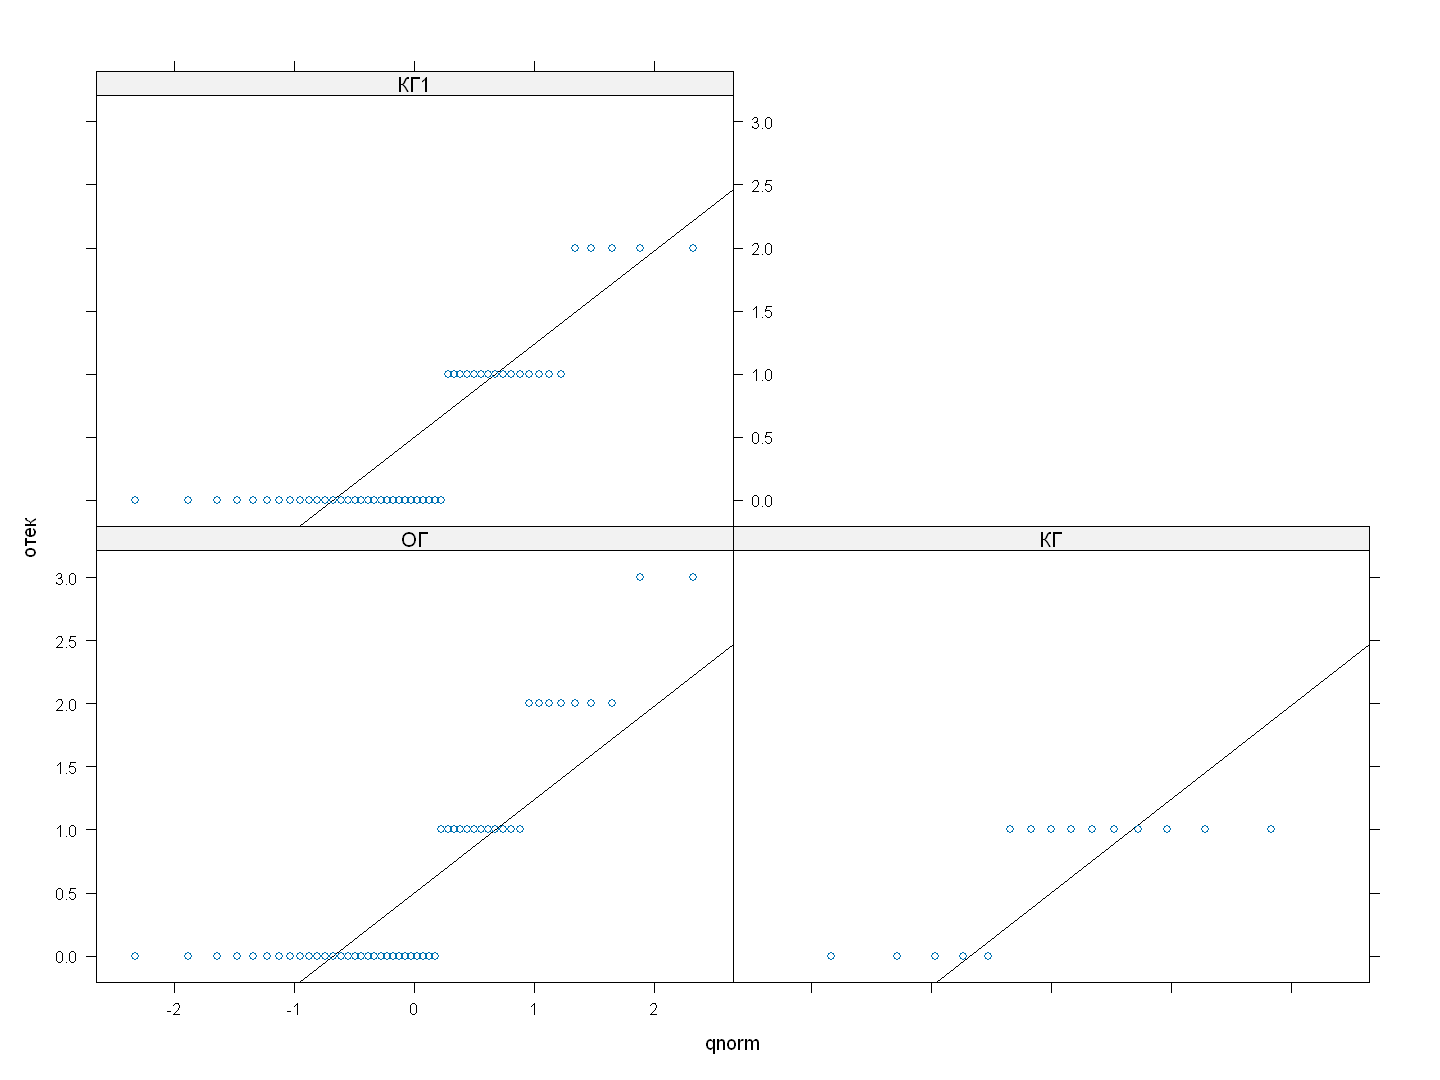

In [24]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

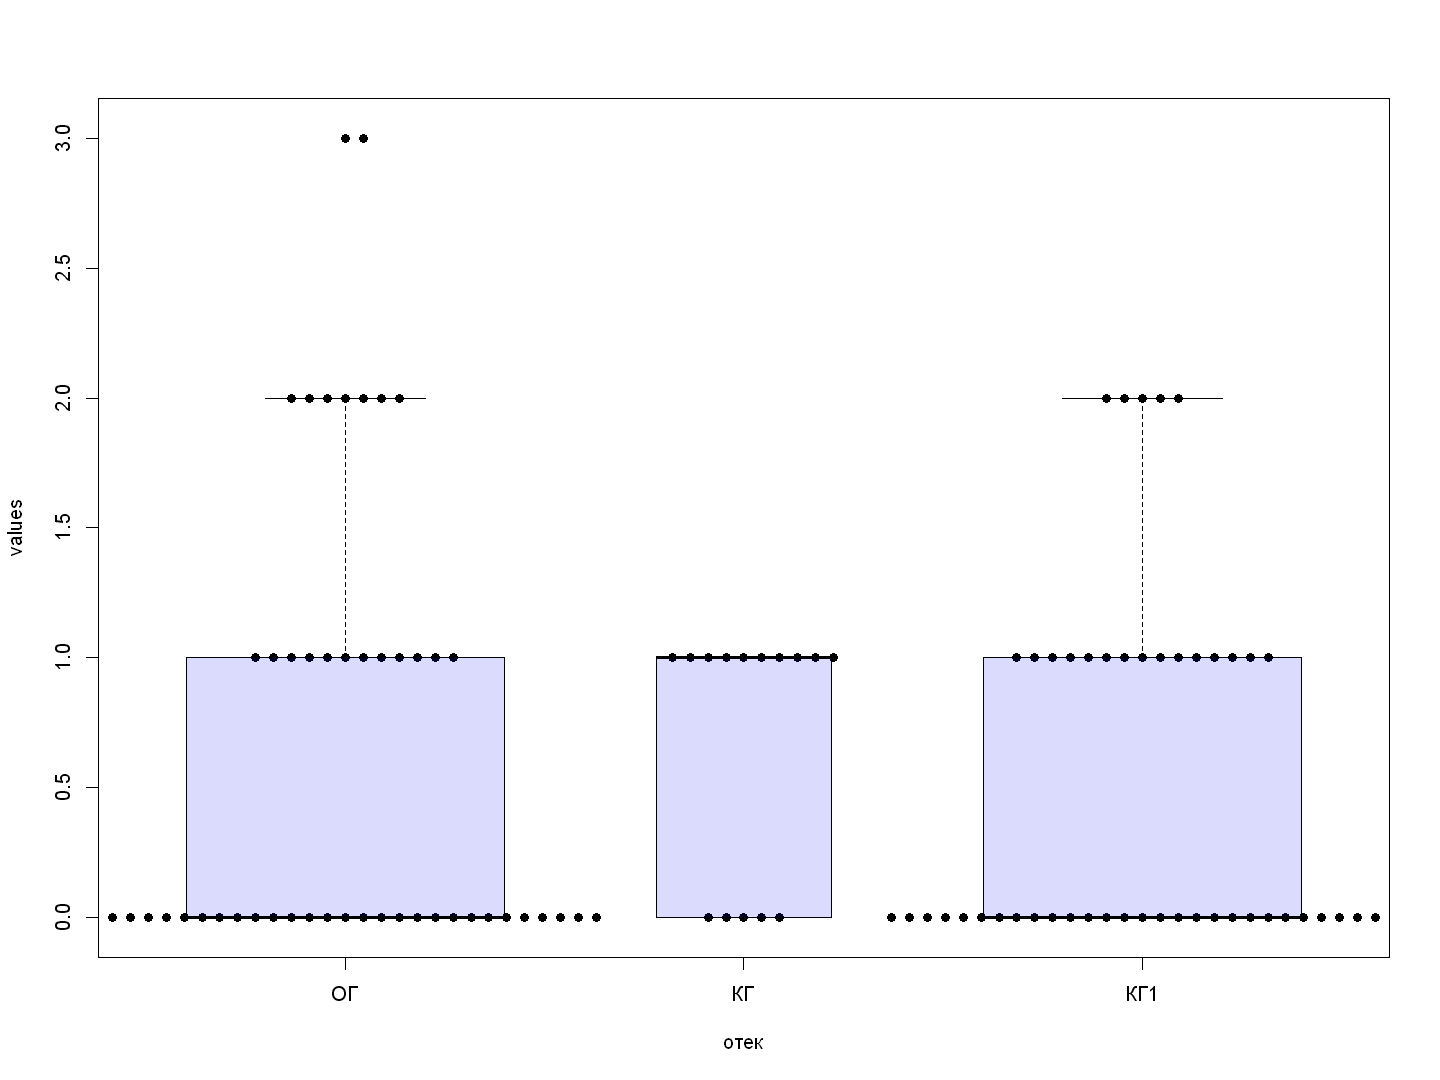

In [25]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [26]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 1.6041, df = 2, p-value = 0.4484

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
         obs.dif critical.dif stat.signif
ОГ-КГ   7.766667     23.49816       FALSE
ОГ-КГ1  3.250000     15.96385       FALSE
КГ-КГ1 11.016667     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 327.5, p-value = 0.4182
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -0.81821, p-value = 0.4431
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1317.5, p-value = 0.5994
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Te

## реснички эпителия

### Общее

In [27]:
parname <- "реснички эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

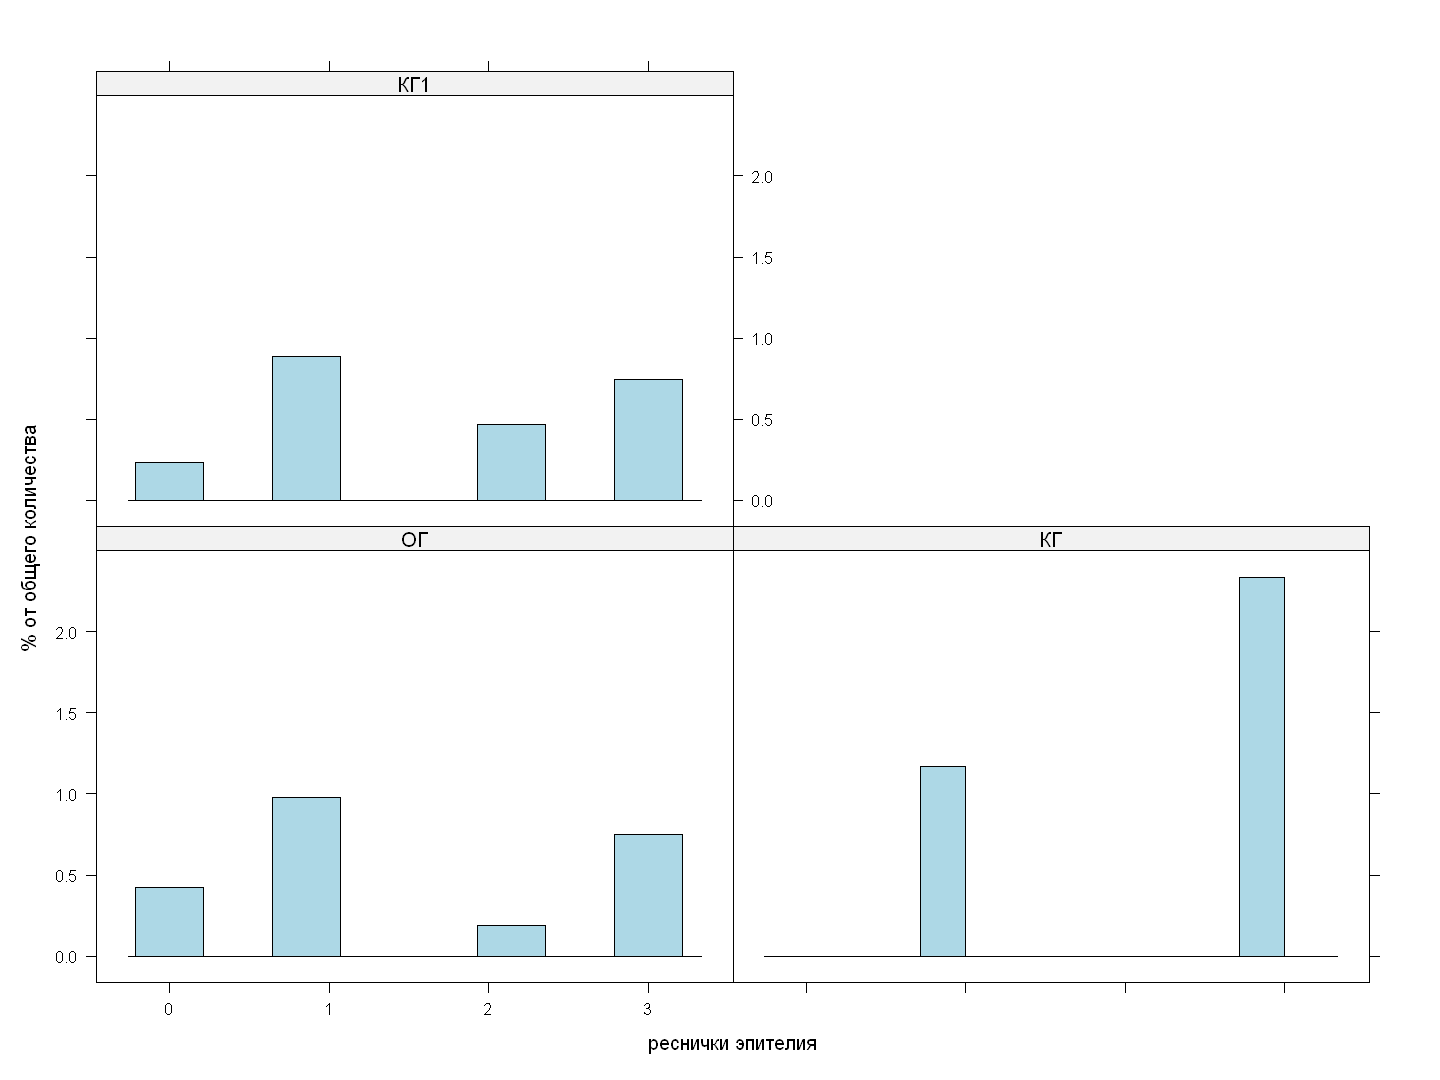

In [28]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [29]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  1.540000 1.1286618   2  0   1   1   3    3     50
КГ  2.333333 0.9759001   2  1   1   3   3    3     15
КГ1 1.740000 1.0263866   2  0   1   2   3    3     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1,1,3,3,1.540000,1.1286618,50,0
КГ,1,1,3,3,3,2.333333,0.9759001,15,0
КГ1,0,1,2,3,3,1.740000,1.0263866,50,0


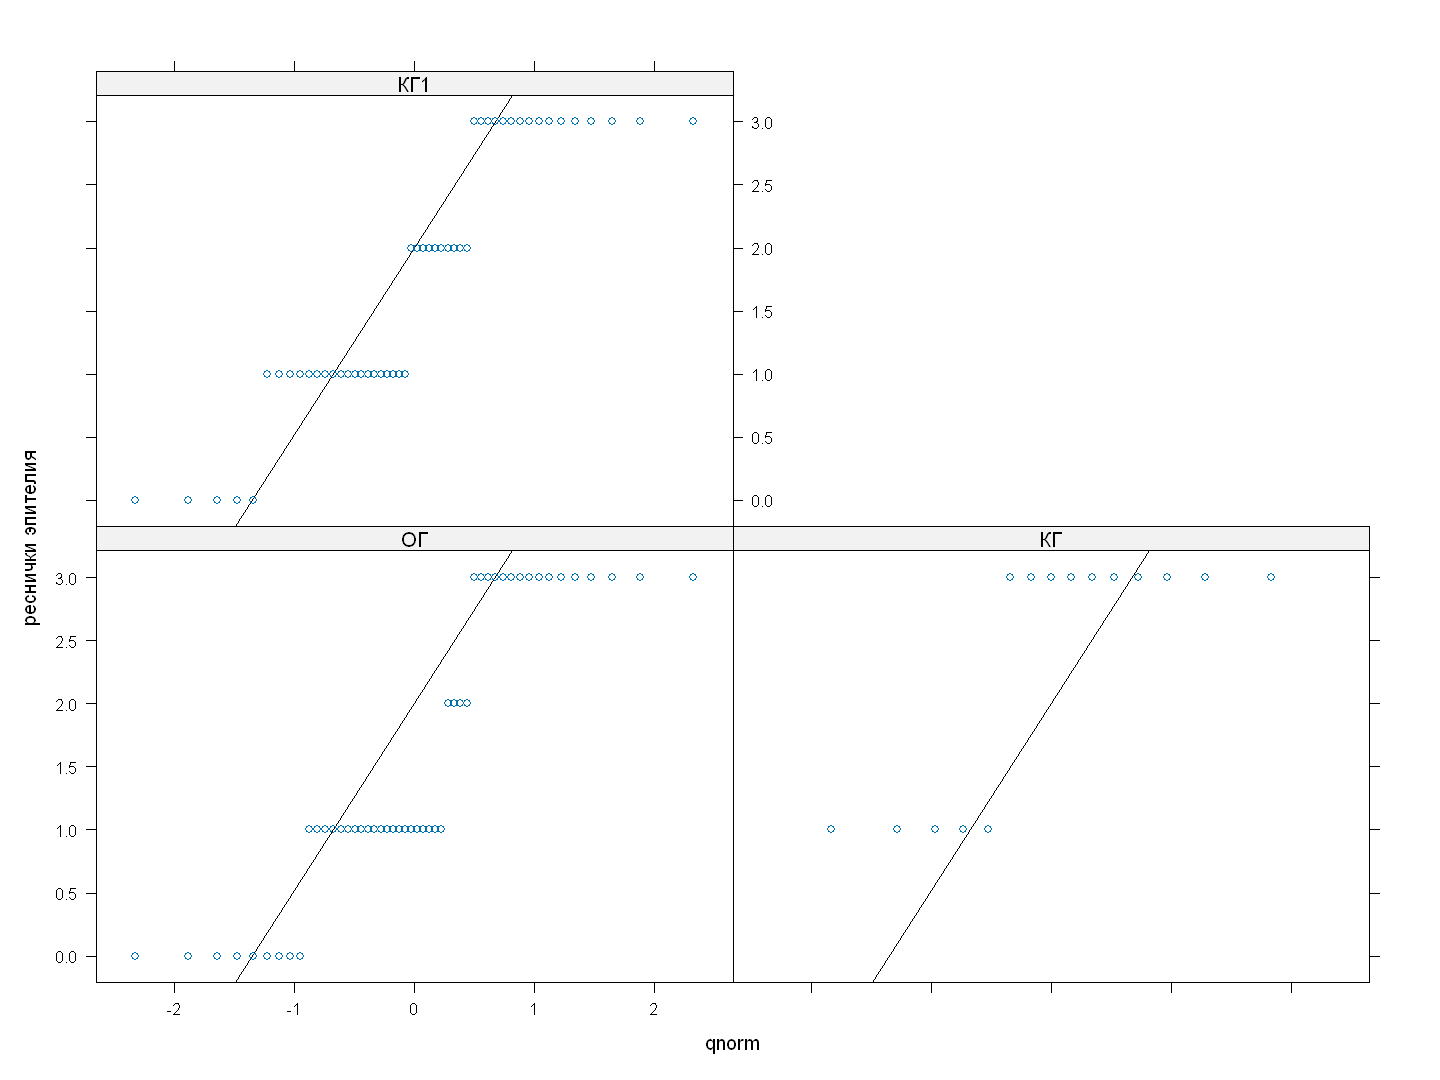

In [30]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

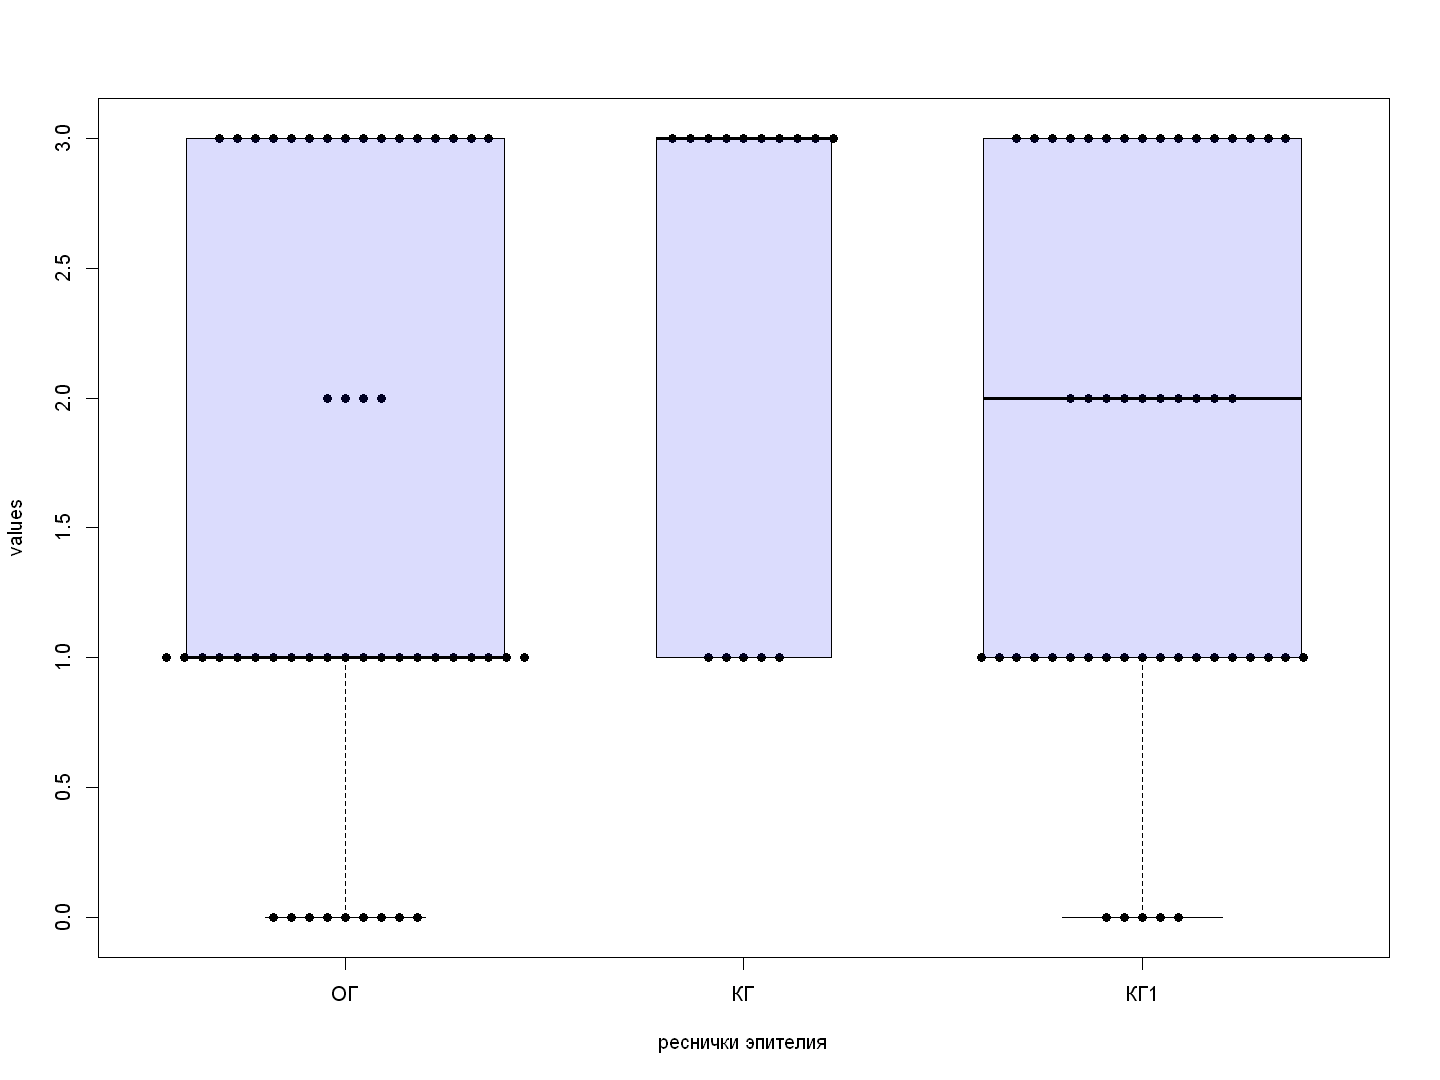

In [31]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [32]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 6.1328, df = 2, p-value = 0.04659

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  22.88333     23.49816       FALSE
ОГ-КГ1  5.90000     15.96385       FALSE
КГ-КГ1 16.98333     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 232.5, p-value = 0.01773
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -2.3797, p-value = 0.01639
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1115, p-value = 0.3278
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test



## фиброз

### Общее

In [33]:
parname <- "фиброз"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

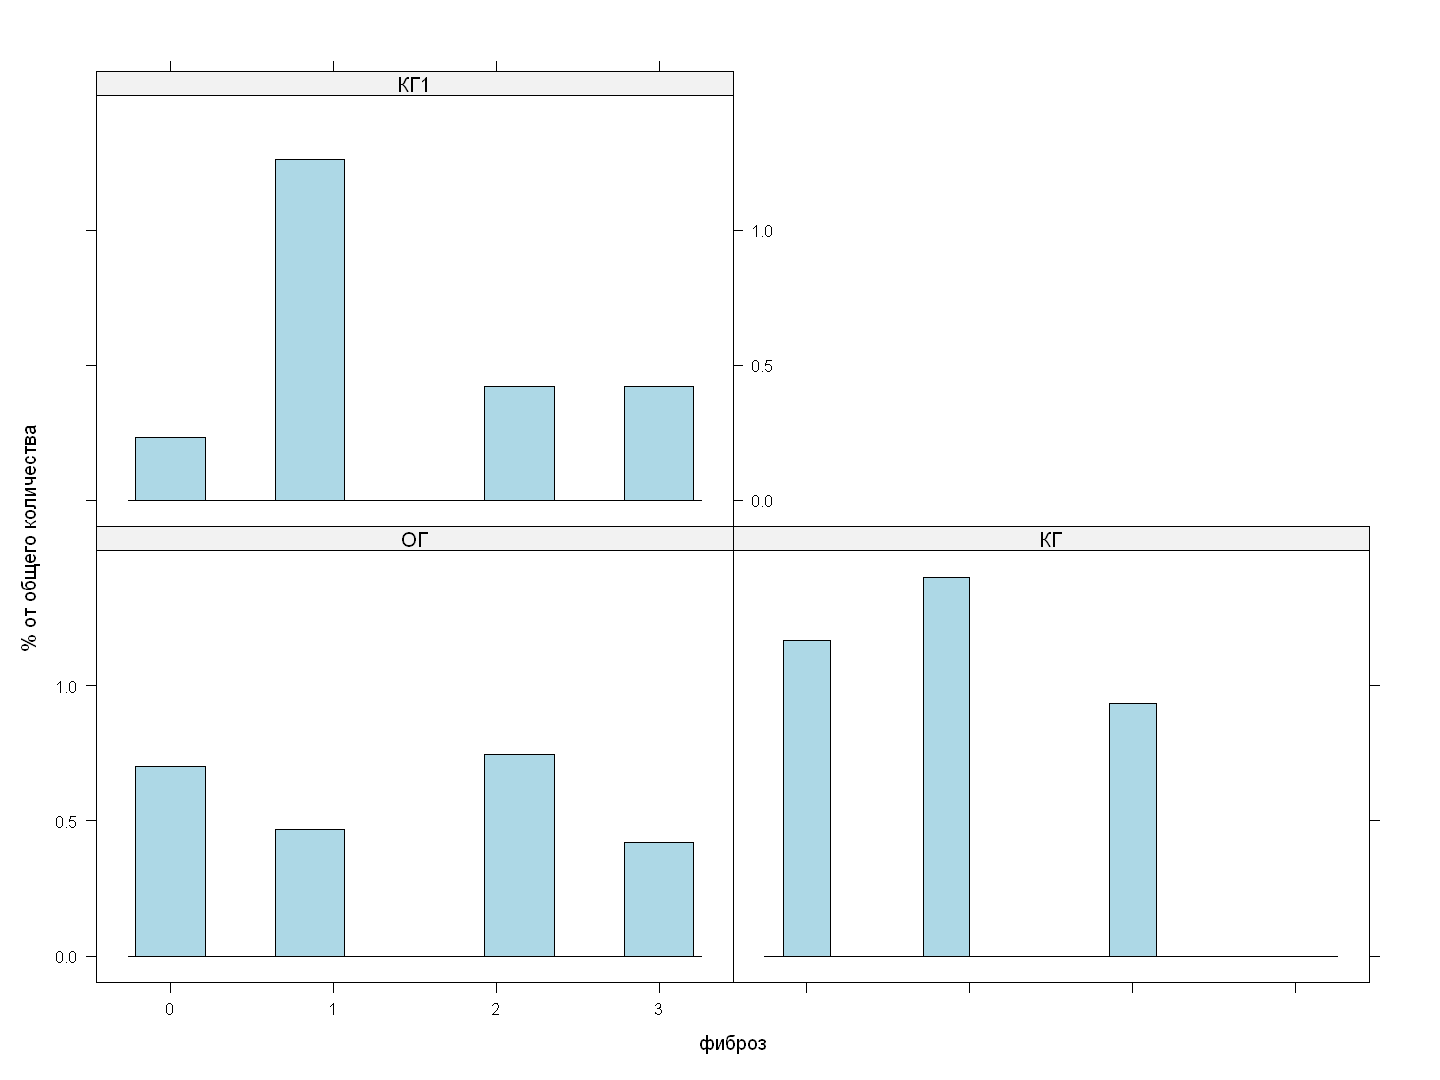

In [34]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [35]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  1.3800000 1.1045361 2.0  0   0 1.5 2.0    3     50
КГ  0.9333333 0.7988086 1.5  0   0 1.0 1.5    2     15
КГ1 1.4400000 0.9071147 1.0  0   1 1.0 2.0    3     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,1.5,2.0,3,1.3800000,1.1045361,50,0
КГ,0,0,1.0,1.5,2,0.9333333,0.7988086,15,0
КГ1,0,1,1.0,2.0,3,1.4400000,0.9071147,50,0


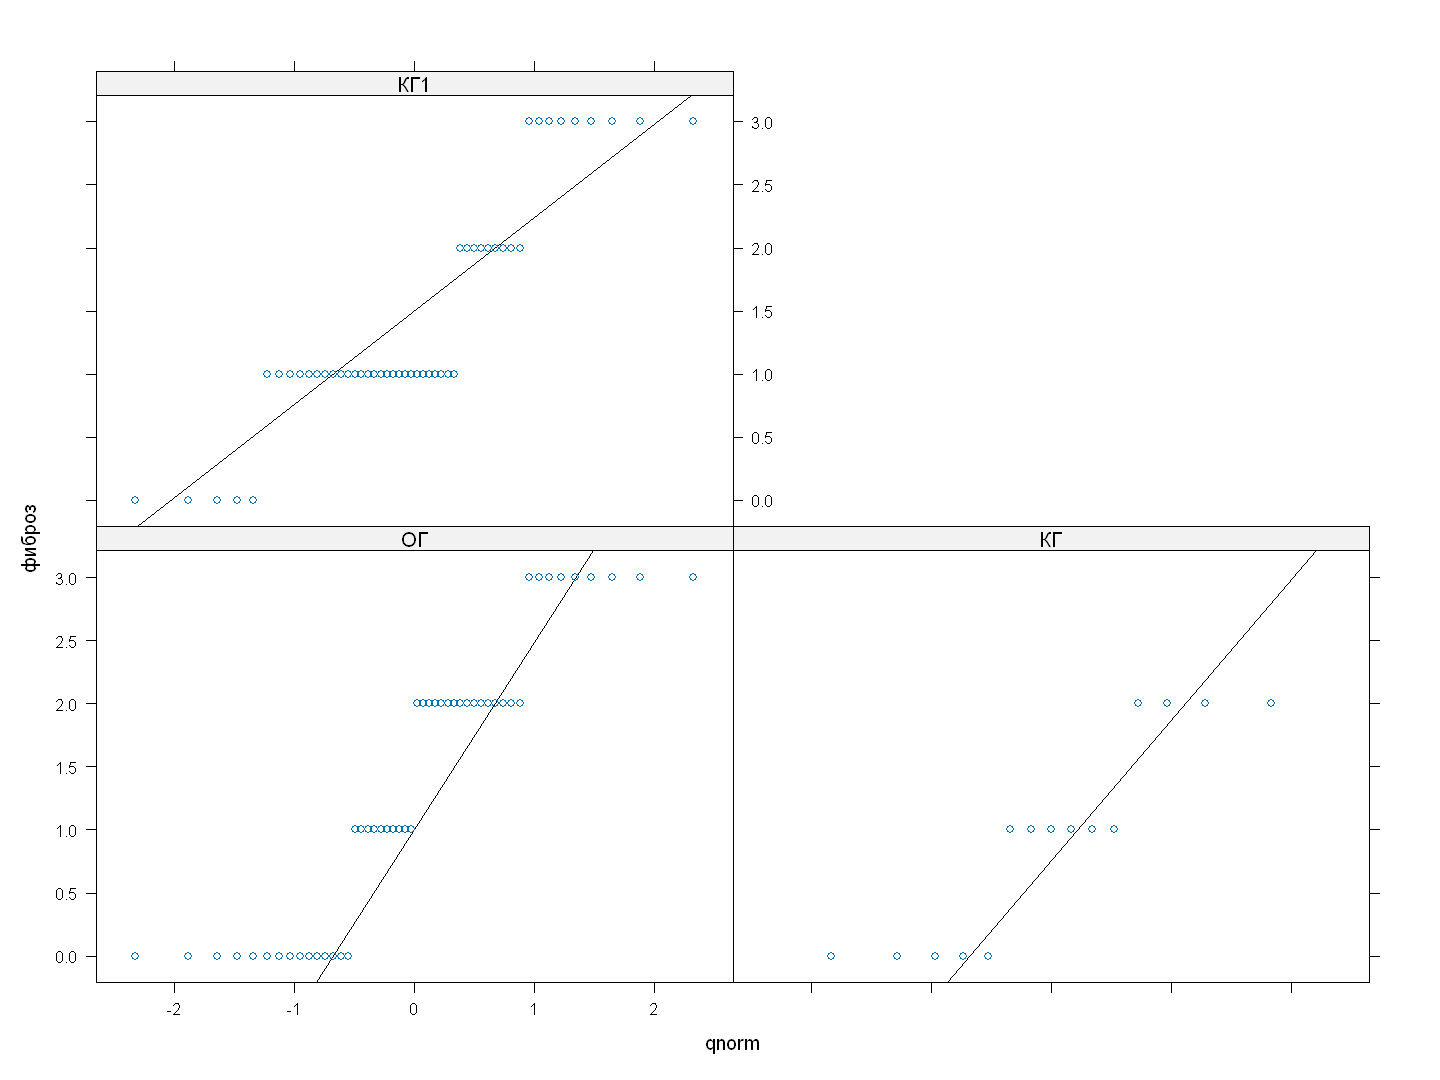

In [36]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

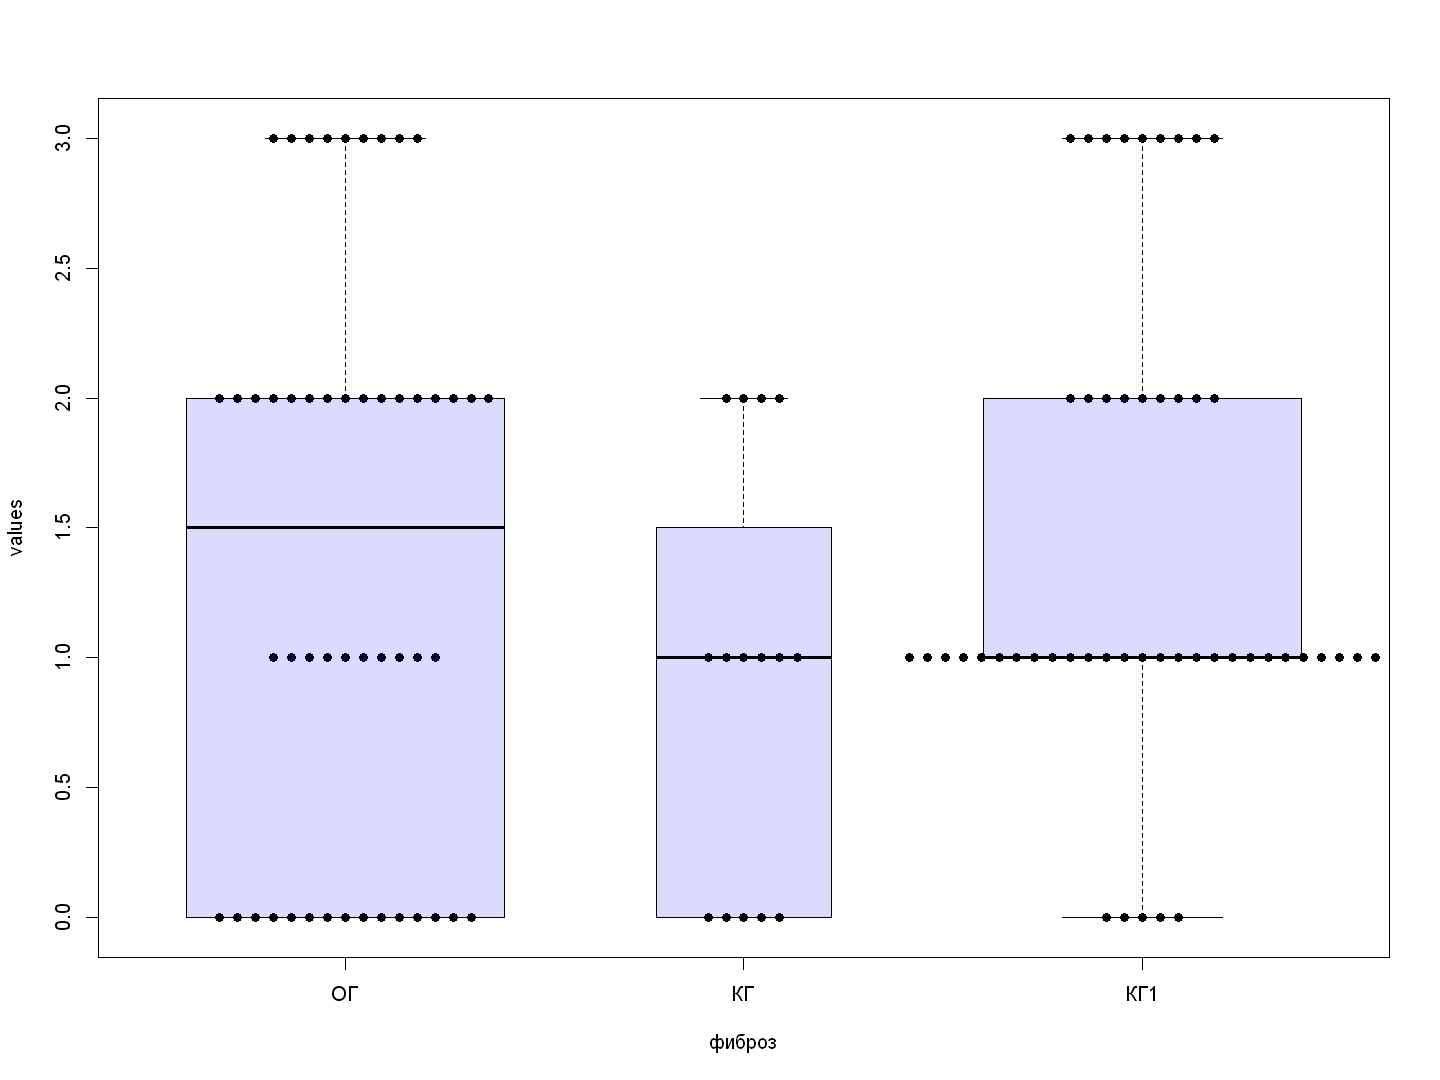

In [37]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [38]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 2.8176, df = 2, p-value = 0.2444

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  13.76333     23.49816       FALSE
ОГ-КГ1  1.76000     15.96385       FALSE
КГ-КГ1 15.52333     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 460.5, p-value = 0.1687
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 1.3846, p-value = 0.1751
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1216, p-value = 0.8097
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data

## гиперплазия респираторного эпителия

### Общее

In [39]:
parname <- "гиперплазия респираторного эпителия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

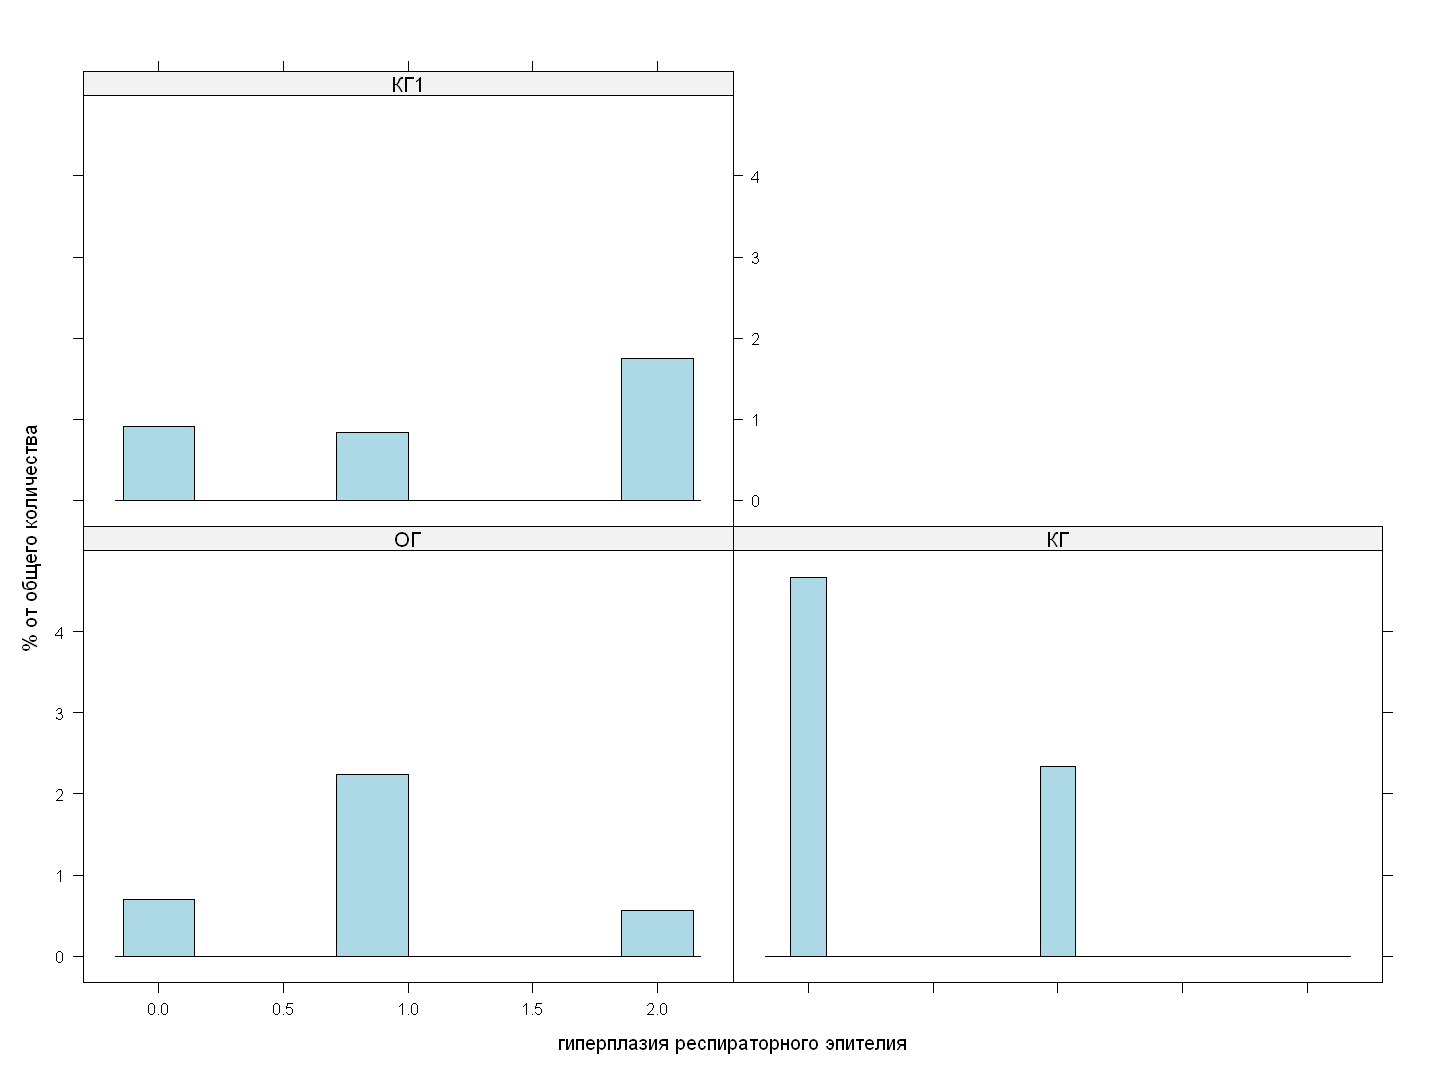

In [40]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [41]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

         mean        sd  IQR 0%  25% 50% 75% 100% data:n
ОГ  0.9600000 0.6047432 0.00  0 1.00 1.0   1    2     50
КГ  0.3333333 0.4879500 1.00  0 0.00 0.0   1    1     15
КГ1 1.2400000 0.8466019 1.75  0 0.25 1.5   2    2     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,1.00,1.0,1,2,0.9600000,0.6047432,50,0
КГ,0,0.00,0.0,1,1,0.3333333,0.4879500,15,0
КГ1,0,0.25,1.5,2,2,1.2400000,0.8466019,50,0


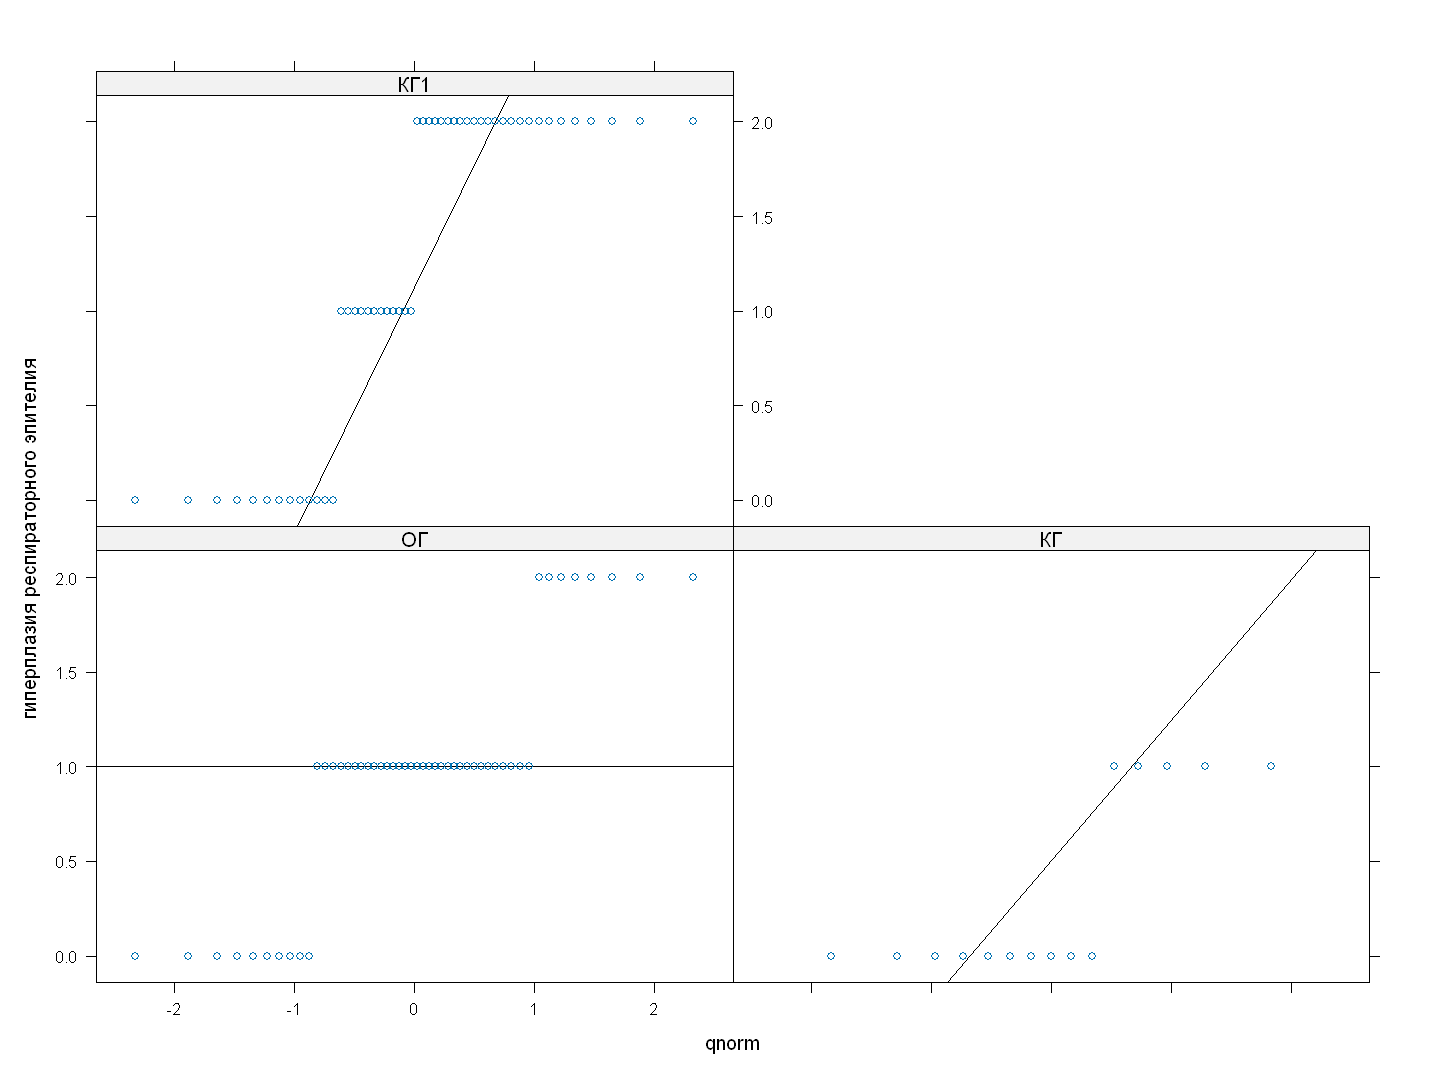

In [42]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

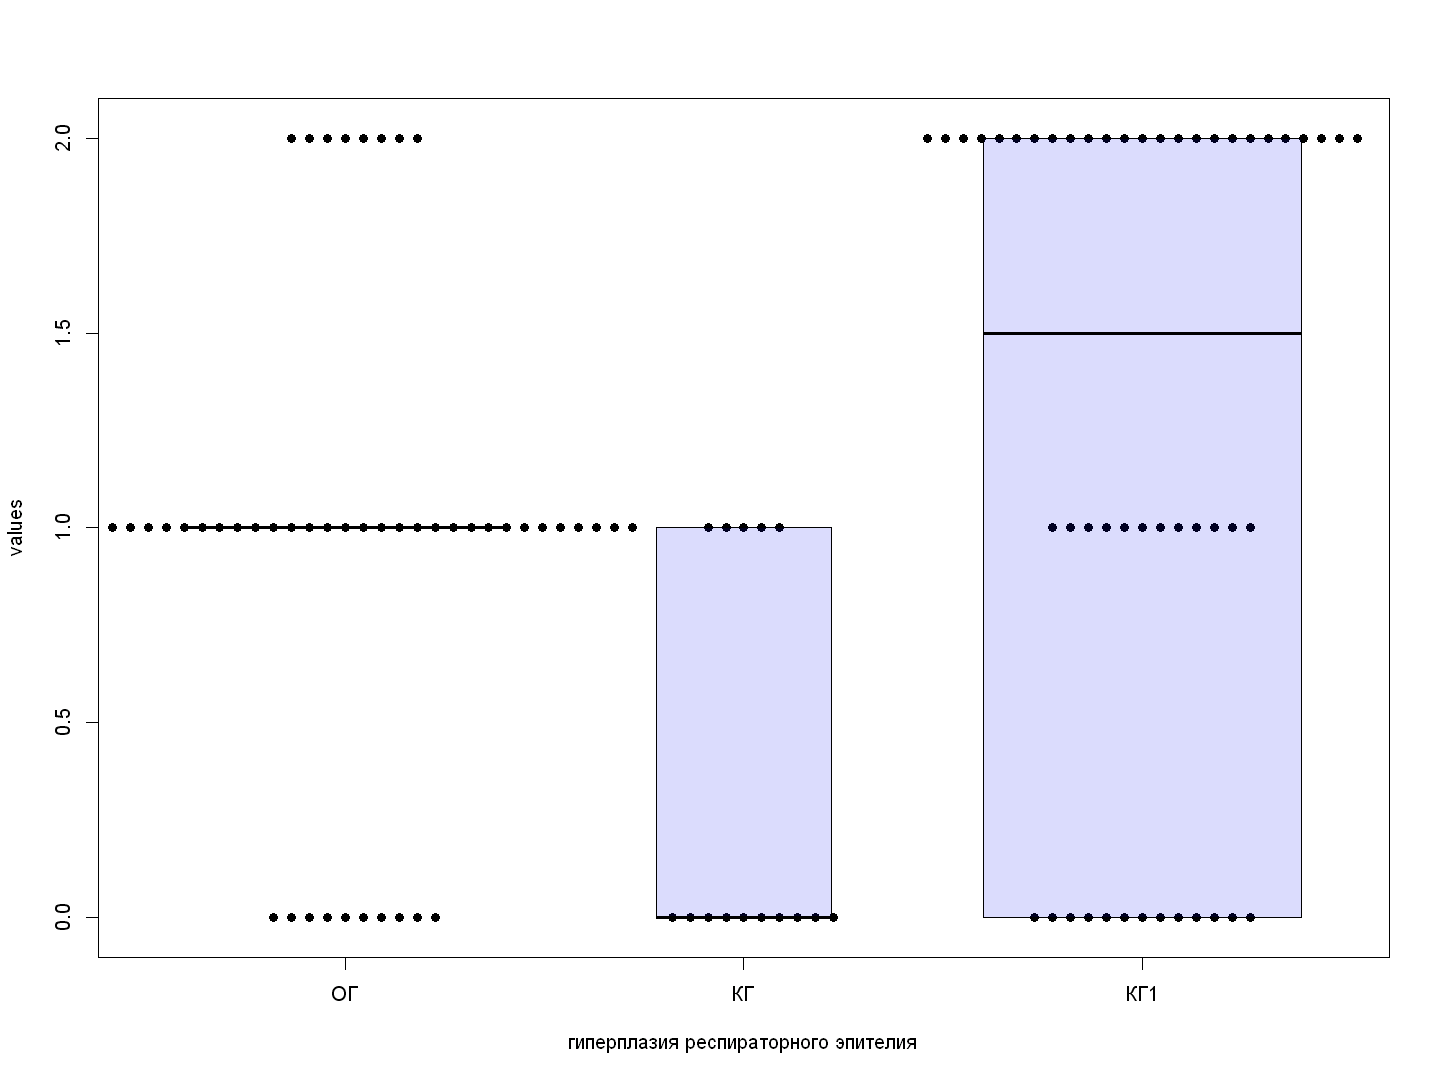

In [43]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [44]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 16.628, df = 2, p-value = 0.0002451

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  25.69333     23.49816        TRUE
ОГ-КГ1 11.48000     15.96385       FALSE
КГ-КГ1 37.17333     23.49816        TRUE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 570, p-value = 0.0006295
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 3.4273, p-value = 0.0007264
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 973, p-value = 0.04062
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Tes

## плоскоклеточная метаплазия

### Общее

In [45]:
parname <- "плоскоклеточная метаплазия"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

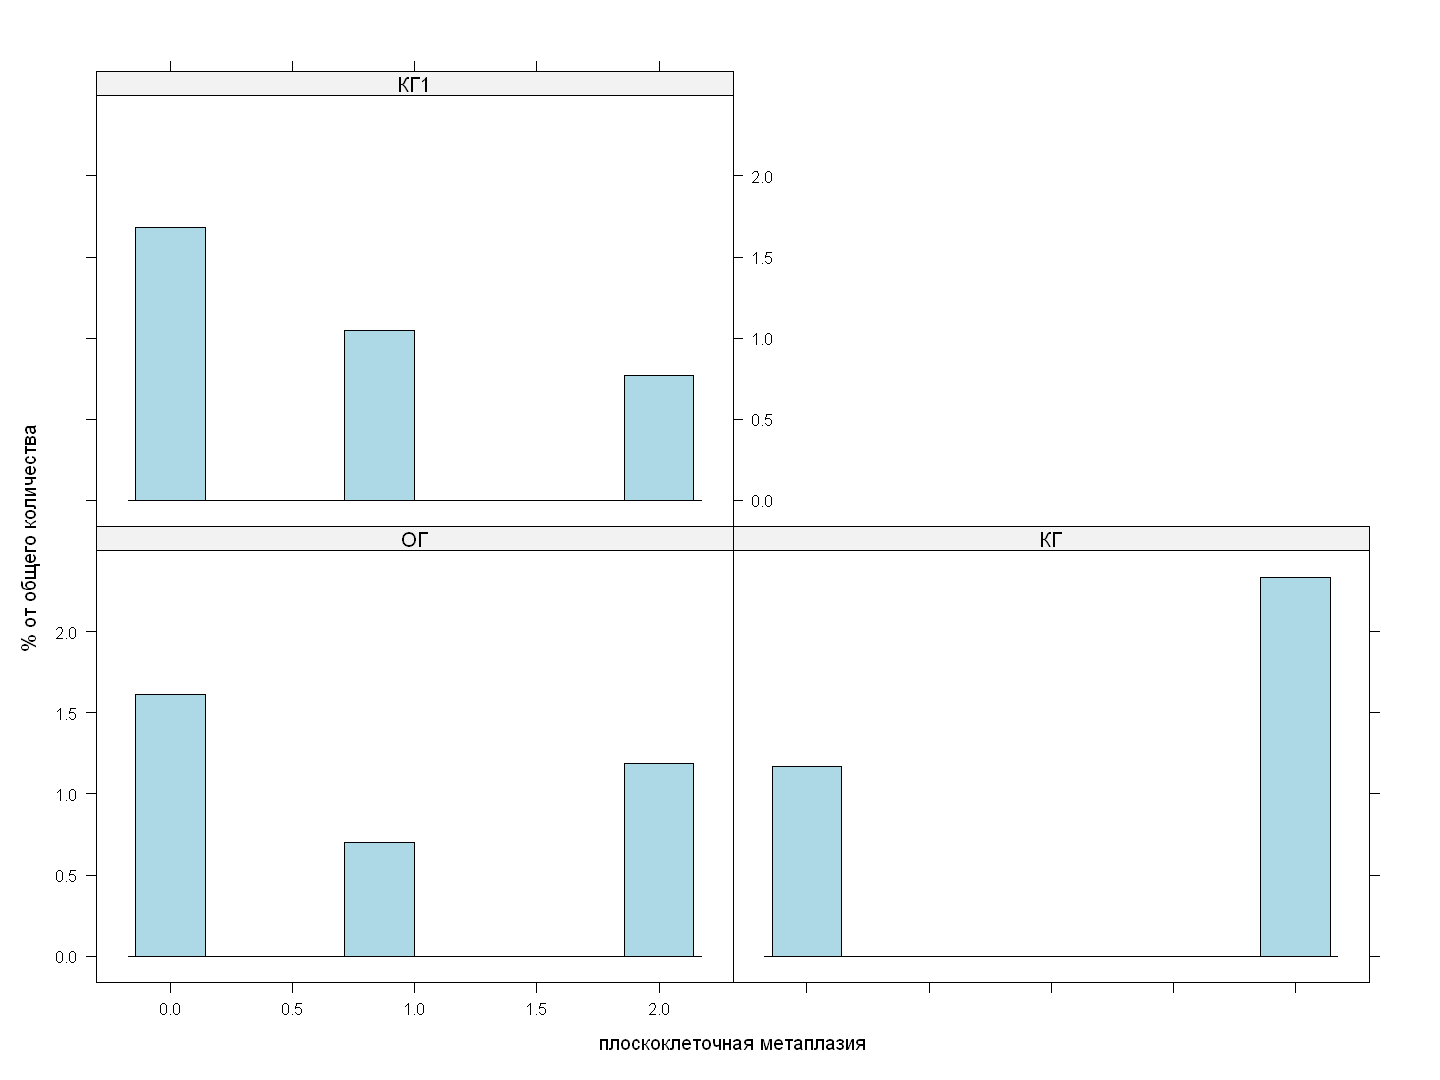

In [46]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

In [47]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

        mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ  0.880000 0.8953394   2  0   0   1   2    2     50
КГ  1.333333 0.9759001   2  0   0   2   2    2     15
КГ1 0.740000 0.8033095   1  0   0   1   1    2     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,1,2,2,0.880000,0.8953394,50,0
КГ,0,0,2,2,2,1.333333,0.9759001,15,0
КГ1,0,0,1,1,2,0.740000,0.8033095,50,0


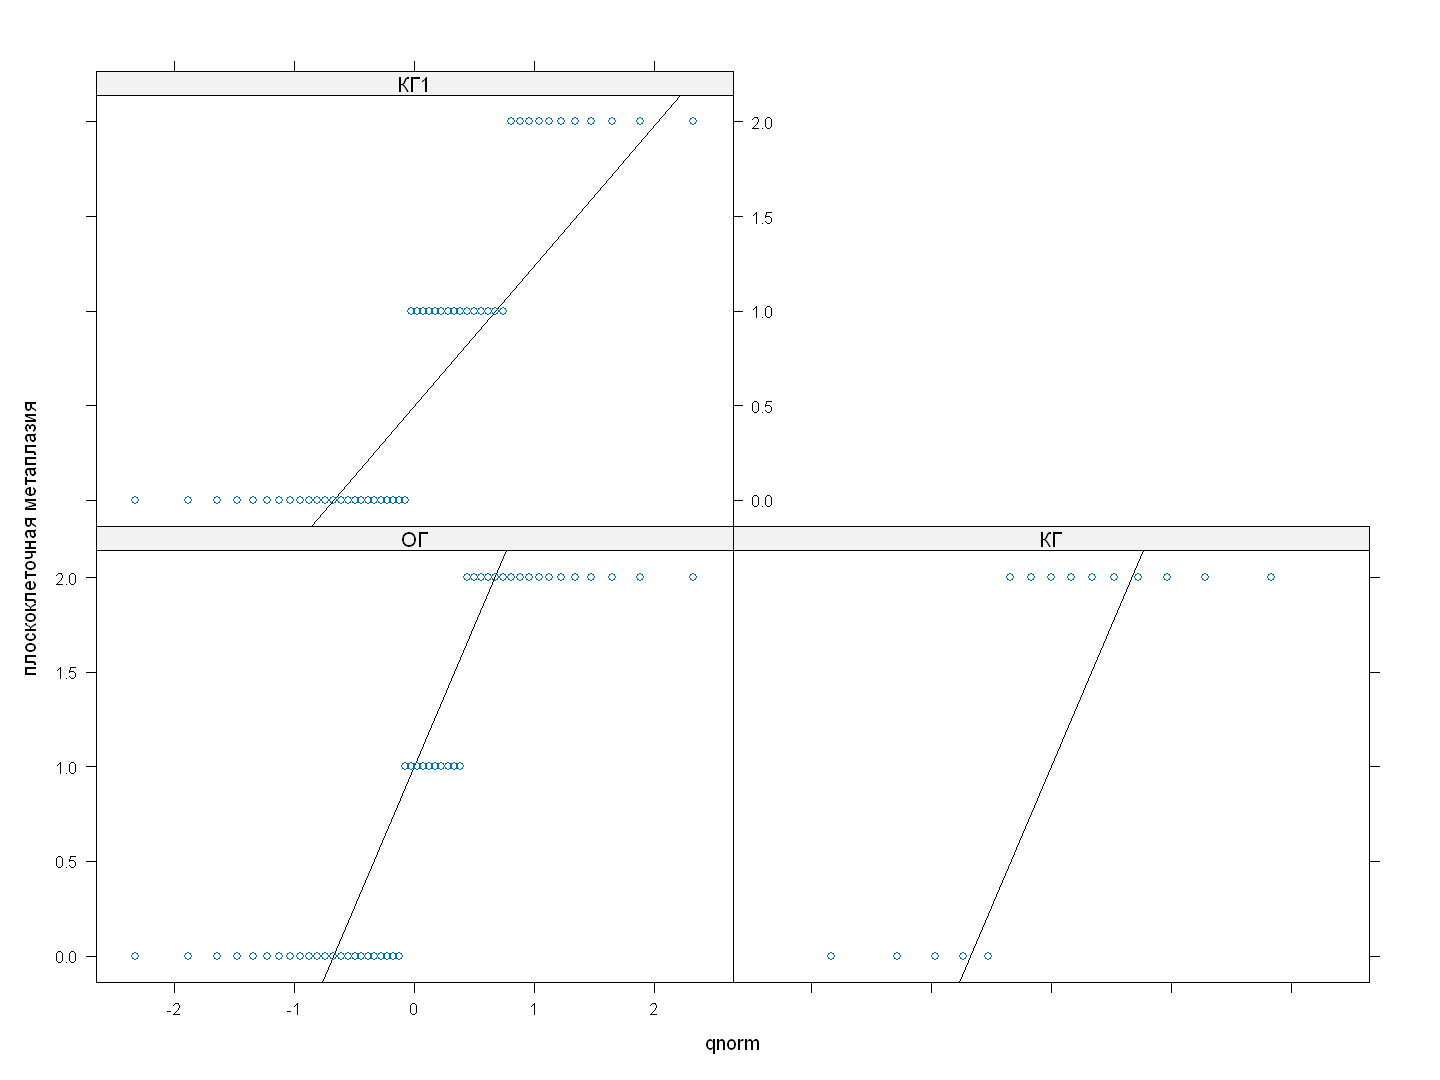

In [48]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

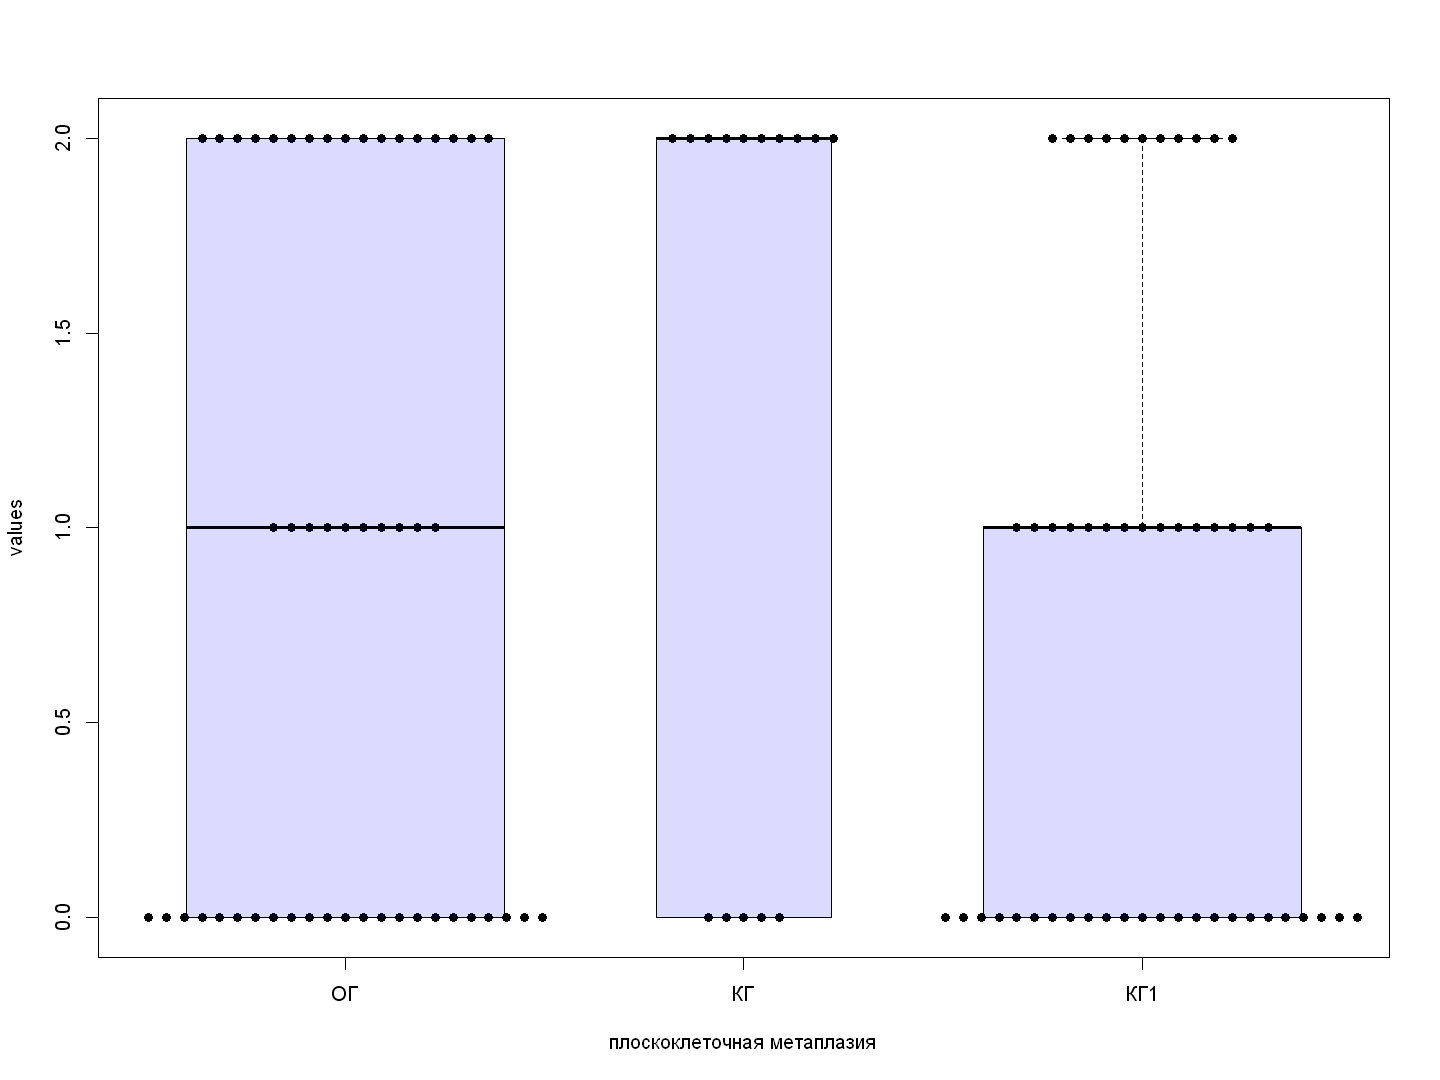

In [49]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [50]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      ))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 4.685, df = 2, p-value = 0.09609

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
        obs.dif critical.dif stat.signif
ОГ-КГ  15.16667     23.49816       FALSE
ОГ-КГ1  4.55000     15.96385       FALSE
КГ-КГ1 19.71667     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 277.5, p-value = 0.1004
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = -1.6515, p-value = 0.1127
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1347.5, p-value = 0.4705
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

d

## эозинофилы

### Общее

In [51]:
parname <- "эозинофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [52]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [53]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ   0.5 1.0738069   0  0   0   0   0    3     50
КГ   0.2 0.4140393   0  0   0   0   0    1     15
КГ1  0.0 0.0000000   0  0   0   0   0    0     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,3,0.5,1.0738069,50,0
КГ,0,0,0,0,1,0.2,0.4140393,15,0
КГ1,0,0,0,0,0,0.0,0.0000000,50,0


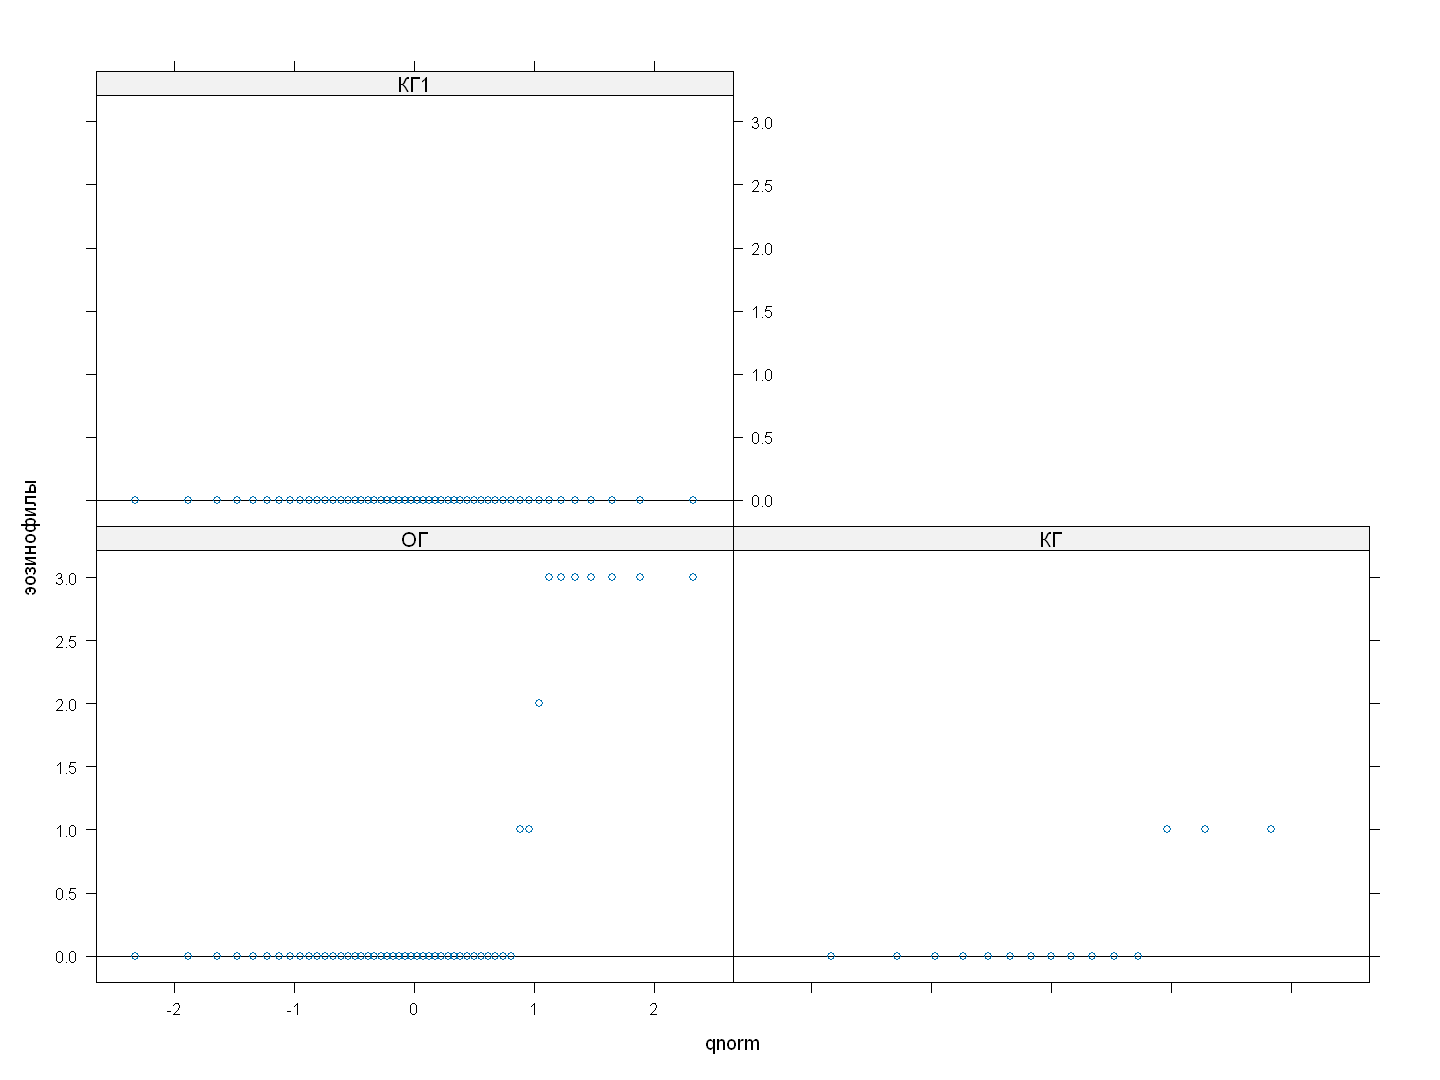

In [54]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

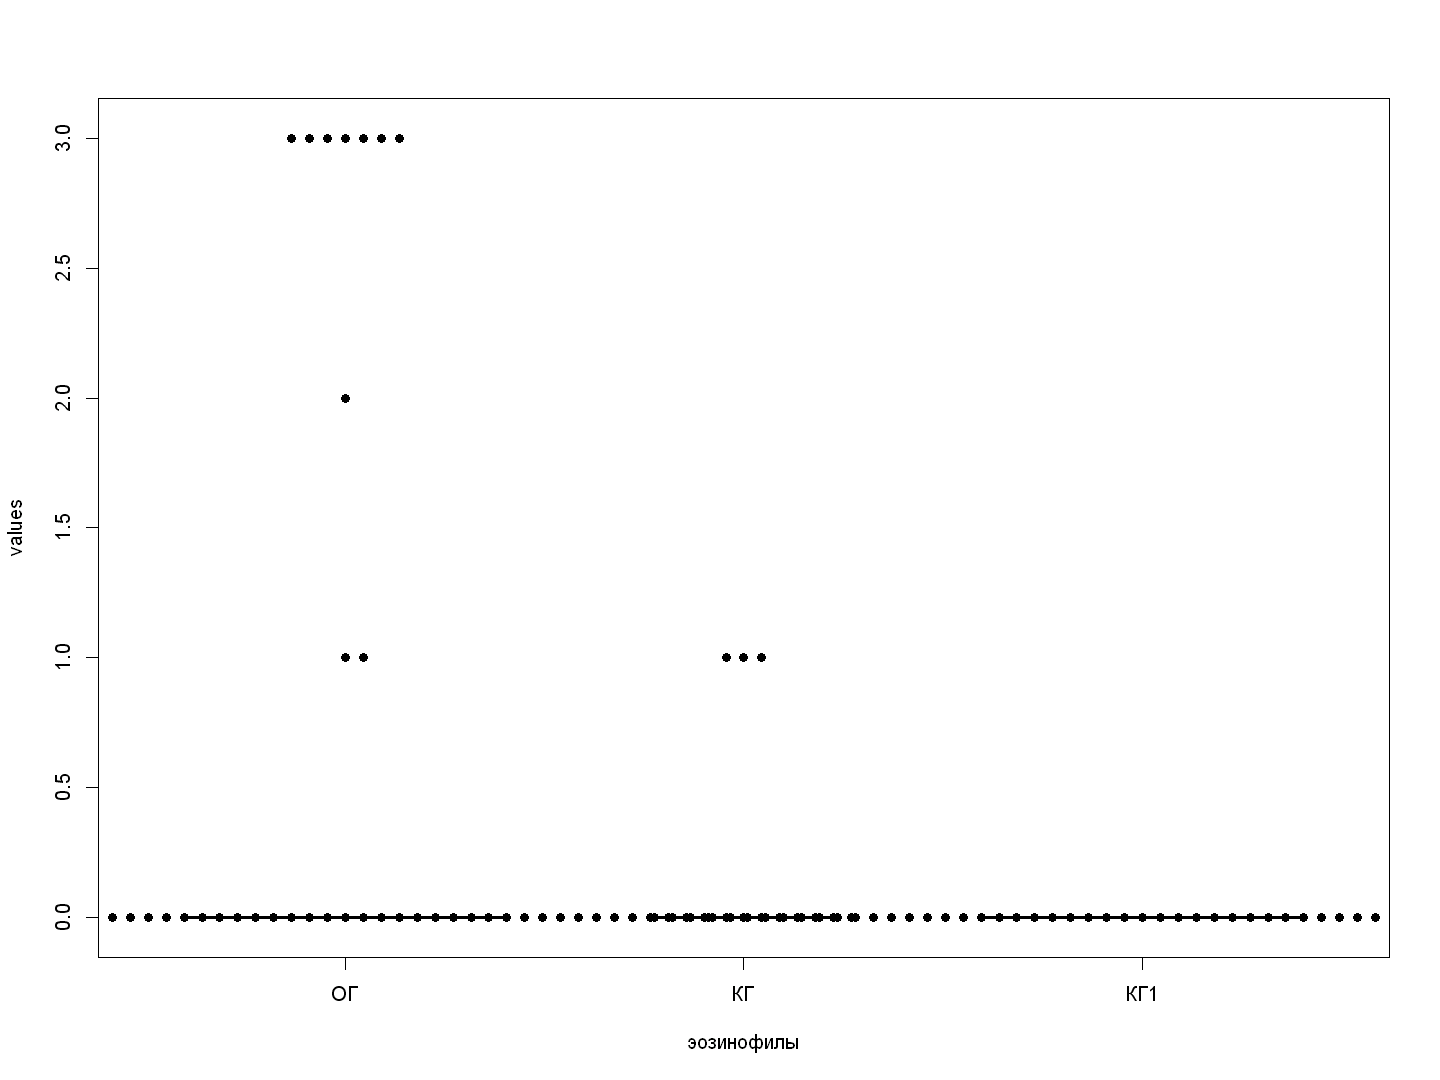

In [55]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [56]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 11.172, df = 2, p-value = 0.003751

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
       obs.dif critical.dif stat.signif
ОГ-КГ     1.04     23.49816       FALSE
ОГ-КГ1   11.74     15.96385       FALSE
КГ-КГ1   10.70     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 387, p-value = 0.7974
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 0.2679, p-value = 0.7253
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1500, p-value = 0.0009463
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:

## нейтрофилы

### Общее

In [57]:
parname <- "нейтрофилы"
values <- lor[[parname]]
parameter <- lor[[groupping_variable]]

In [58]:
try(histogram(~ values | parameter, ylab = "% от общего количества", col = "light blue", xlab = parname))

Error in breaks(x, ...) : `width' too small.


In [59]:
numSummary(values,
  statistics = c("mean", "sd", "IQR", "quantiles"),
  quantiles = c(0, .25, .5, .75, 1), groups = parameter
)
favstats(values ~ parameter)

    mean        sd IQR 0% 25% 50% 75% 100% data:n
ОГ   0.1 0.3030458   0  0   0   0   0    1     50
КГ   0.0 0.0000000   0  0   0   0   0    0     15
КГ1  0.0 0.0000000   0  0   0   0   0    0     50

parameter,min,Q1,median,Q3,max,mean,sd,n,missing
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
ОГ,0,0,0,0,1,0.1,0.3030458,50,0
КГ,0,0,0,0,0,0.0,0.0000000,15,0
КГ1,0,0,0,0,0,0.0,0.0000000,50,0


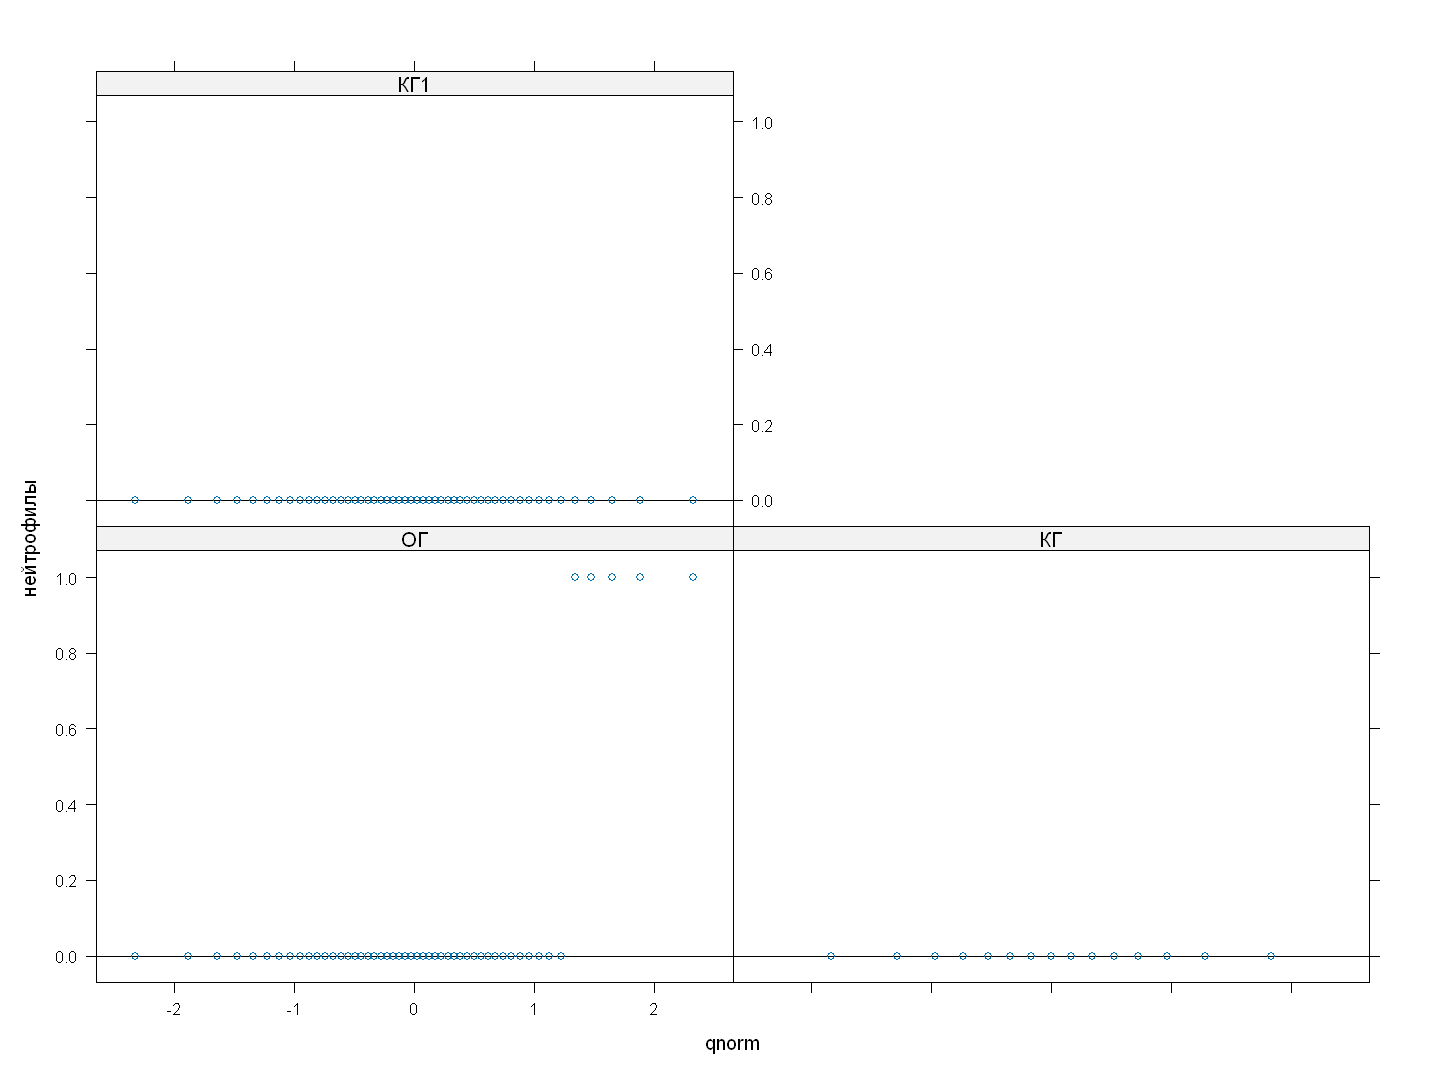

In [60]:
qqmath(~ values | parameter, panel = function(x, ...) {
  panel.qqmathline(x, ...)
  panel.qqmath(x, ...)
}, ylab = parname)

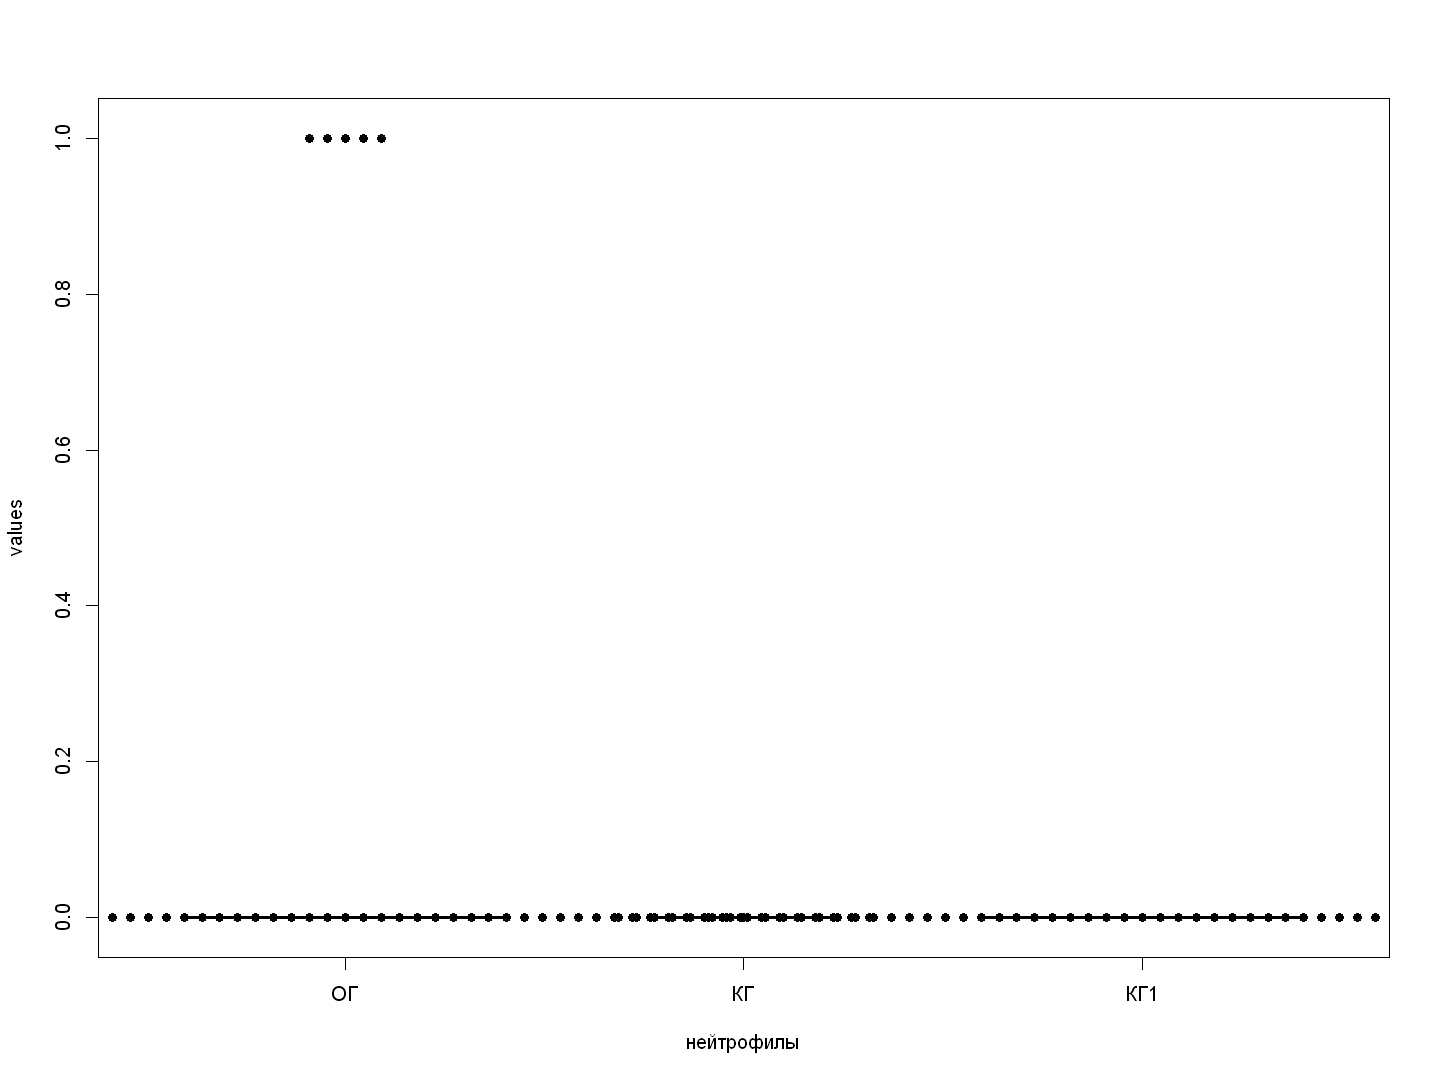

In [61]:
beeswarm(values ~ parameter, data = lor, method = "swarm", pch = 16, xlab = parname)
boxplot(values ~ parameter, data = lor, add = TRUE, varwidth = TRUE, outline = FALSE, col = "#0000ff22")
# abline(h= (12), lty=2, col = "grey")

### Сравнение, распределение не нормальное

In [62]:
if (nlevels(parameter) < 3) {
  wilcox.test(values ~ parameter)
  independence_test(values ~ parameter,
    data = lor,
    alternative = "two.sided",
    ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
    xtrafo = function(data) trafo(data, ordered_trafo = ff)
  )
} else {
  try(print(kruskal.test(values ~ parameter)))
  print(kruskalmc(values ~ parameter))

  cat("\n==========\nPairwise comparison \n")
  for (i in 1:(nlevels(parameter) - 1)) {
    for (j in (i + 1):nlevels(parameter)) {
      cat("\nГруппы — ", levels(parameter)[i], ", ", levels(parameter)[j])
      ss <- subset(lor, parameter == levels(lor[[groupping_variable]])[i] | parameter == levels(lor[[groupping_variable]])[j])
      try(print(wilcox.test(ss[[parname]] ~ ss[[groupping_variable]], exact = TRUE)))
      try(print(independence_test(ss[[parname]] ~ ss[[groupping_variable]],
        data = ss,
        alternative = "two.sided",
        distribution = "exact",
        ytrafo = function(data) trafo(data, numeric_trafo = rank_trafo),
        xtrafo = function(data) trafo(data, ordered_trafo = ff)
      )))
    }
  }
}


	Kruskal-Wallis rank sum test

data:  values by parameter
Kruskal-Wallis chi-squared = 6.7364, df = 2, p-value = 0.03445

Multiple comparison test after Kruskal-Wallis 
alpha: 0.05 
Comparisons
       obs.dif critical.dif stat.signif
ОГ-КГ     5.75     23.49816       FALSE
ОГ-КГ1    5.75     15.96385       FALSE
КГ-КГ1    0.00     23.49816       FALSE

Pairwise comparison 

Группы —  ОГ ,  КГ
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 412.5, p-value = 0.212
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  ss[[parname]] by ss[[groupping_variable]] (ОГ, КГ)
Z = 1.2649, p-value = 0.3326
alternative hypothesis: two.sided


Группы —  ОГ ,  КГ1
	Wilcoxon rank sum test with continuity correction

data:  ss[[parname]] by ss[[groupping_variable]]
W = 1375, p-value = 0.02299
alternative hypothesis: true location shift is not equal to 0


	Exact General Independence Test

data:  